# 운전 적성 검사 - Cut-point 분석 및 Indicator Feature 생성
---
## 목표: 위험비율이 튀는 구간을 정확히 찾아 Indicator Feature 만들기

## 1. 환경 설정

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print("환경 설정 완료!")

환경 설정 완료!


In [2]:
# 데이터 로드
train_meta = pd.read_csv("./data/train.csv")
train_A_raw = pd.read_csv("./data/train/A.csv")
train_B_raw = pd.read_csv("./data/train/B.csv")

overall_risk = train_meta['Label'].mean()
print(f"전체 위험군 비율: {overall_risk:.4f}")
print(f"A검사 샘플: {len(train_A_raw)}, B검사 샘플: {len(train_B_raw)}")

전체 위험군 비율: 0.0289
A검사 샘플: 647241, B검사 샘플: 297526


## 2. 유틸 함수 (script04 기반)

In [3]:
def convert_age(val):
    if pd.isna(val):
        return np.nan
    try:
        base = int(str(val)[:-1])
        return base if str(val)[-1].lower() == "a" else base + 5
    except:
        return np.nan

def seq_mean(series):
    s = series.fillna("").astype(str)
    df = s.str.split(",", expand=True).replace("", np.nan).astype(float)
    return df.mean(axis=1)

def seq_std(series):
    s = series.fillna("").astype(str)
    df = s.str.split(",", expand=True).replace("", np.nan).astype(float)
    return df.std(axis=1)

def seq_rate(series, target="1"):
    def calc(x):
        if not x:
            return np.nan
        items = str(x).split(",")
        return items.count(str(target)) / len(items) if items else np.nan
    return series.fillna("").apply(calc)

def masked_mean(cond_series, val_series, mask_val):
    cond_df = cond_series.fillna("").str.split(",", expand=True).replace("", np.nan).astype(float)
    val_df = val_series.fillna("").str.split(",", expand=True).replace("", np.nan).astype(float)
    mask = (cond_df == mask_val)
    return val_df.where(mask).mean(axis=1)

print("유틸 함수 정의 완료!")

유틸 함수 정의 완료!


## 3. A검사 기본 피처 생성

In [4]:
# A검사 전처리
A_df = train_A_raw.copy()
A_df = A_df.merge(train_meta[['Test_id', 'Label']], on='Test_id', how='left')

# Age
A_df['Age_num'] = A_df['Age'].map(convert_age)
A_df['Age_z'] = (A_df['Age_num'] - A_df['Age_num'].mean()) / A_df['Age_num'].std()

# A1 (주의집중, 반응속도)
A_df['A1_resp_rate'] = seq_rate(A_df['A1-3'], '1')
A_df['A1_rt_mean'] = seq_mean(A_df['A1-4'])
A_df['A1_rt_std'] = seq_std(A_df['A1-4'])
A_df['A1_rt_cv'] = A_df['A1_rt_std'] / (A_df['A1_rt_mean'] + 1e-6)

# A4 (Stroop 과제)
A_df['A4_acc_rate'] = seq_rate(A_df['A4-3'], '1')
A_df['A4_rt_mean'] = seq_mean(A_df['A4-5'])
A_df['A4_stroop_diff'] = (
    masked_mean(A_df['A4-1'], A_df['A4-5'], 2) - 
    masked_mean(A_df['A4-1'], A_df['A4-5'], 1)
)

# A5 (변화 탐지)
A_df['A5_acc_rate'] = seq_rate(A_df['A5-2'], '1')
A_df['A5_acc_nonchange'] = masked_mean(A_df['A5-1'], A_df['A5-2'], 1)
A_df['A5_acc_change'] = pd.concat([
    masked_mean(A_df['A5-1'], A_df['A5-2'], 2),
    masked_mean(A_df['A5-1'], A_df['A5-2'], 3),
    masked_mean(A_df['A5-1'], A_df['A5-2'], 4)
], axis=1).mean(axis=1)
A_df['A5_change_nonchange_gap'] = A_df['A5_acc_change'] - A_df['A5_acc_nonchange']

# A6, A7, A9 종합 점수
a6_cols = [c for c in A_df.columns if c.startswith('A6-')]
a7_cols = [c for c in A_df.columns if c.startswith('A7-')]
a9_cols = [c for c in A_df.columns if c.startswith('A9-')]

if a6_cols:
    A_df['A6_total'] = A_df[a6_cols].sum(axis=1)
if a7_cols:
    A_df['A7_total'] = A_df[a7_cols].sum(axis=1)
if a9_cols:
    A_df['A9_total'] = A_df[a9_cols].sum(axis=1)

# 인지/정서 점수
A_df['CogScore_A'] = 0
if 'A6_total' in A_df.columns:
    A_df['CogScore_A'] += A_df['A6_total']
if 'A7_total' in A_df.columns:
    A_df['CogScore_A'] += A_df['A7_total']
if 'A9-4' in A_df.columns:
    A_df['CogScore_A'] += A_df['A9-4'].fillna(0)

A_df['EmoScore_A'] = 0
for col in ['A9-1', 'A9-2', 'A9-5']:
    if col in A_df.columns:
        A_df['EmoScore_A'] += A_df[col].fillna(0)

print(f"A검사 피처 생성 완료: {A_df.shape}")
print(f"Label 결측: {A_df['Label'].isnull().sum()}")

A검사 피처 생성 완료: (647241, 56)
Label 결측: 0


## 4. B검사 기본 피처 생성

In [5]:
# B검사 전처리
B_df = train_B_raw.copy()
B_df = B_df.merge(train_meta[['Test_id', 'Label']], on='Test_id', how='left')

# Age
B_df['Age_num'] = B_df['Age'].map(convert_age)
B_df['Age_z'] = (B_df['Age_num'] - B_df['Age_num'].mean()) / B_df['Age_num'].std()

# B3, B4 (주의집중, Stroop-like)
B_df['B3_acc_rate'] = seq_rate(B_df['B3-1'], '1')
B_df['B3_rt_mean'] = seq_mean(B_df['B3-2'])
B_df['B3_rt_std'] = seq_std(B_df['B3-2'])

B_df['B4_acc_rate'] = seq_rate(B_df['B4-1'], '1')
B_df['B4_rt_mean'] = seq_mean(B_df['B4-2'])
B_df['B4_rt_std'] = seq_std(B_df['B4-2'])

# B9, B10 (지속 주의력, 이중과제)
if all(c in B_df.columns for c in ['B9-1', 'B9-2', 'B9-3', 'B9-4', 'B9-5']):
    B9_AUD_TARGET = 15.0
    B9_AUD_DIST = 35.0
    B_df['B9_aud_overall_acc'] = (
        (B_df['B9-1'].astype(float) + B_df['B9-4'].astype(float)) / (B9_AUD_TARGET + B9_AUD_DIST)
    )
    B_df['B9_vis_err_rate'] = B_df['B9-5'].astype(float) / 32.0

if all(c in B_df.columns for c in ['B10-1', 'B10-2', 'B10-3', 'B10-4', 'B10-5']):
    B10_AUD_TARGET = 20.0
    B10_AUD_DIST = 60.0
    B_df['B10_aud_overall_acc'] = (
        (B_df['B10-1'].astype(float) + B_df['B10-4'].astype(float)) / (B10_AUD_TARGET + B10_AUD_DIST)
    )
    B_df['B10_vis1_err_rate'] = B_df['B10-5'].astype(float) / 52.0
    
    if 'B9_aud_overall_acc' in B_df.columns:
        B_df['B10_multitask_cost_aud'] = B_df['B10_aud_overall_acc'] - B_df['B9_aud_overall_acc']
    if 'B9_vis_err_rate' in B_df.columns:
        B_df['B10_multitask_cost_vis'] = B_df['B10_vis1_err_rate'] - B_df['B9_vis_err_rate']

# RiskScore_B (script04 기반)
eps = 1e-6
B_df['B4_rt_cv'] = B_df['B4_rt_std'] / (B_df['B4_rt_mean'] + eps)
B_df['B3_speed_acc_tradeoff'] = B_df['B3_rt_mean'] / (B_df['B3_acc_rate'] + eps)
B_df['B4_speed_acc_tradeoff'] = B_df['B4_rt_mean'] / (B_df['B4_acc_rate'] + eps)

B_df['RiskScore_B'] = (
    0.25 * B_df['B4_rt_cv'].fillna(0) +
    0.25 * (1 - B_df['B3_acc_rate'].fillna(0)) +
    0.25 * (1 - B_df['B4_acc_rate'].fillna(0)) +
    0.25 * B_df['B3_speed_acc_tradeoff'].fillna(0)
)

print(f"B검사 피처 생성 완료: {B_df.shape}")
print(f"Label 결측: {B_df['Label'].isnull().sum()}")

B검사 피처 생성 완료: (297526, 50)
Label 결측: 0


## 5. 핵심: 구간별 위험비율 분석 함수

In [6]:
def analyze_bins(df, col, label_col='Label', bins=10, method='quantile'):
    """
    특정 컬럼을 구간으로 나눠서 위험비율 분석
    
    Parameters:
    -----------
    df : DataFrame
    col : str - 분석할 컬럼명
    label_col : str - 타겟 컬럼명
    bins : int or list - 구간 수 또는 구간 경계값
    method : str - 'quantile' (qcut) or 'uniform' (cut)
    
    Returns:
    --------
    DataFrame - bin별 위험비율, 샘플 수, 구간 경계
    """
    tmp = df[[col, label_col]].dropna().copy()
    
    if len(tmp) == 0:
        print(f"⚠️  {col}: 데이터 없음")
        return None
    
    try:
        if method == 'quantile':
            tmp['bin'] = pd.qcut(tmp[col], q=bins, duplicates='drop')
        else:
            tmp['bin'] = pd.cut(tmp[col], bins=bins, duplicates='drop')
    except Exception as e:
        print(f"⚠️  {col}: binning 실패 - {e}")
        return None
    
    result = tmp.groupby('bin', observed=True).agg({
        label_col: ['mean', 'count']
    }).reset_index()
    
    result.columns = ['bin', 'risk_rate', 'count']
    result['risk_rate'] = result['risk_rate'].round(5)
    result['coverage'] = (result['count'] / len(tmp) * 100).round(2)
    
    # 구간 경계 추출
    result['left'] = result['bin'].apply(lambda x: x.left)
    result['right'] = result['bin'].apply(lambda x: x.right)
    
    return result

def plot_bin_analysis(result, col, overall_risk, figsize=(14, 5)):
    """
    구간별 위험비율 시각화
    """
    if result is None or len(result) == 0:
        return
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # 위험비율 bar plot
    x = np.arange(len(result))
    axes[0].bar(x, result['risk_rate'], color='coral', alpha=0.7, edgecolor='black')
    axes[0].axhline(y=overall_risk, color='red', linestyle='--', linewidth=2, label=f'Overall: {overall_risk:.4f}')
    axes[0].set_xlabel('Bin')
    axes[0].set_ylabel('Risk Rate')
    axes[0].set_title(f'{col} - Risk Rate by Bin', fontsize=12, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f'{i+1}' for i in range(len(result))], rotation=0)
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # 샘플 수
    axes[1].bar(x, result['count'], color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Bin')
    axes[1].set_ylabel('Sample Count')
    axes[1].set_title(f'{col} - Sample Count by Bin', fontsize=12, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f'{i+1}' for i in range(len(result))], rotation=0)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def find_spike_threshold(result, spike_factor=1.5):
    """
    위험비율이 튀는 구간의 threshold 찾기
    
    Parameters:
    -----------
    result : DataFrame - analyze_bins 결과
    spike_factor : float - 전체 평균 대비 몇 배 이상이면 '튐'으로 볼지
    
    Returns:
    --------
    dict - {'low_threshold': float, 'high_threshold': float}
    """
    if result is None or len(result) == 0:
        return None
    
    overall = result['risk_rate'].mean()
    spike_threshold = overall * spike_factor
    
    high_risk_bins = result[result['risk_rate'] >= spike_threshold]
    
    thresholds = {}
    
    if len(high_risk_bins) > 0:
        # 가장 낮은 high risk bin의 left 값
        low_cut = high_risk_bins['left'].min()
        # 가장 높은 high risk bin의 right 값
        high_cut = high_risk_bins['right'].max()
        
        thresholds['low_threshold'] = low_cut
        thresholds['high_threshold'] = high_cut
        thresholds['spike_bins'] = len(high_risk_bins)
        thresholds['max_risk_rate'] = high_risk_bins['risk_rate'].max()
    
    return thresholds

print("구간 분석 함수 정의 완료!")

구간 분석 함수 정의 완료!


## 6. A검사 핵심 피처 구간 분석

### 6.1 A4_acc_rate (정확도)


[A검사] A4_acc_rate 구간 분석


[10분위 quantile 기준]
               bin  risk_rate   count  coverage   left  right
0  (-0.001, 0.962]    0.02706   80609     12.45 -0.001  0.962
1   (0.962, 0.975]    0.02345   96786     14.95  0.962  0.975
2   (0.975, 0.988]    0.02253  183364     28.33  0.975  0.988
3     (0.988, 1.0]    0.02133  286482     44.26  0.988  1.000


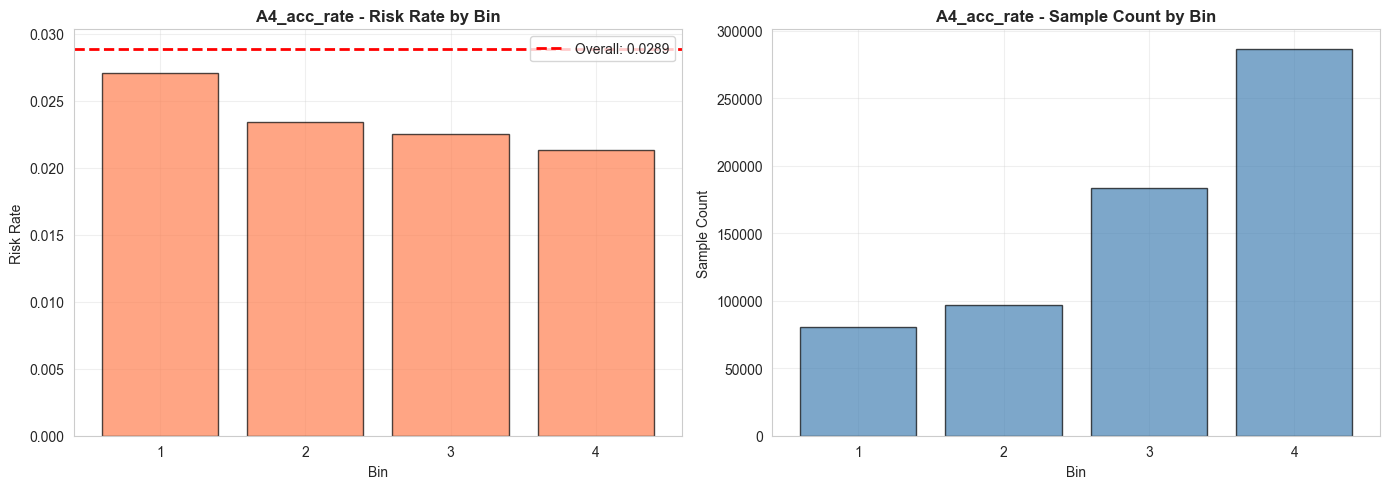


[커스텀 구간 분석]
           bin  risk_rate   count  coverage
0   (0.0, 0.6]    0.06098     164      0.03
1   (0.6, 0.7]    0.05714      70      0.01
2   (0.7, 0.8]    0.06926     231      0.04
3  (0.8, 0.85]    0.02851     491      0.08
4  (0.85, 0.9]    0.03423    2863      0.44
5  (0.9, 0.95]    0.02819   34299      5.30
6  (0.95, 1.0]    0.02230  609119     94.11


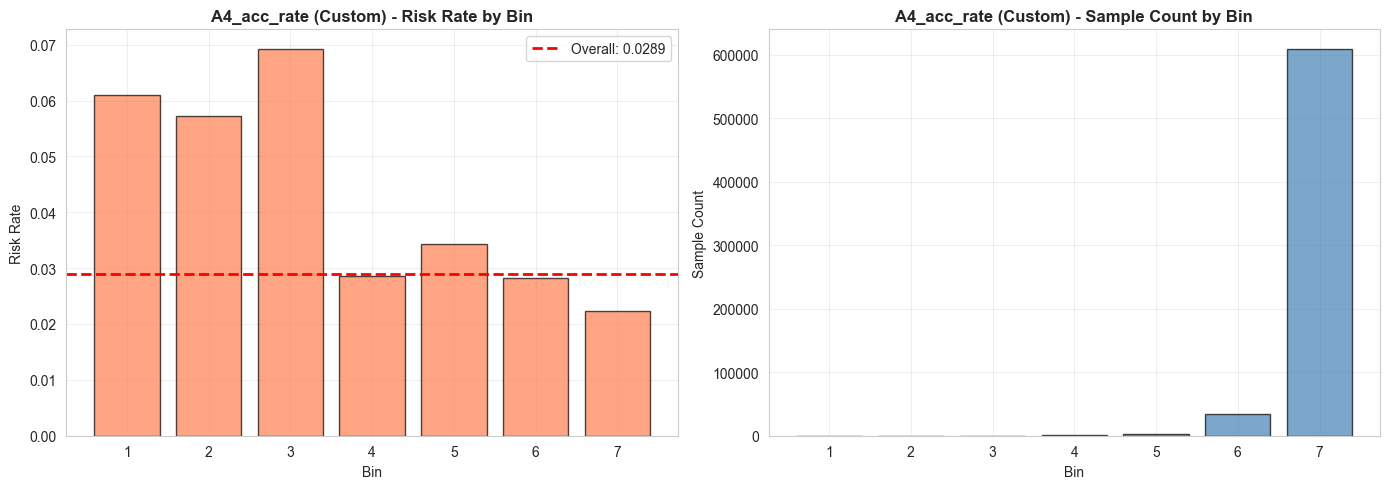

In [7]:
col = 'A4_acc_rate'
print(f"\n{'='*80}")
print(f"[A검사] {col} 구간 분석")
print(f"{'='*80}\n")

# 10분위로 분석
result = analyze_bins(A_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    # Threshold 찾기
    thresholds = find_spike_threshold(result, spike_factor=1.5)
    if thresholds:
        print(f"\n[Spike 구간 분석] (전체 평균의 1.5배 이상)")
        print(f"  - Low threshold: {thresholds['low_threshold']:.4f}")
        print(f"  - High threshold: {thresholds['high_threshold']:.4f}")
        print(f"  - Spike bins: {thresholds['spike_bins']}개")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

# 커스텀 bins로도 시도
custom_bins = [0, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0]
result_custom = analyze_bins(A_df, col, bins=custom_bins, method='uniform')
if result_custom is not None:
    print("\n[커스텀 구간 분석]")
    print(result_custom[['bin', 'risk_rate', 'count', 'coverage']])
    plot_bin_analysis(result_custom, f"{col} (Custom)", overall_risk)

### 6.2 A4_stroop_diff (Stroop 효과)


[A검사] A4_stroop_diff 구간 분석


[10분위 quantile 기준]
                             bin  risk_rate  count  coverage     left  \
0  (-643.0509999999999, -14.175]    0.02316  64737     10.00 -643.051   
1              (-14.175, -12.95]    0.02259  64725     10.00  -14.175   
2                (-12.95, 0.425]    0.02101  64779     10.01  -12.950   
3                 (0.425, 9.775]    0.02126  64667      9.99    0.425   
4                 (9.775, 17.85]    0.02082  64734     10.00    9.775   
5                 (17.85, 25.55]    0.02190  64807     10.01   17.850   
6                (25.55, 33.775]    0.02197  64625      9.98   25.550   
7                 (33.775, 43.5]    0.02234  64741     10.00   33.775   
8                  (43.5, 57.85]    0.02374  64703     10.00   43.500   
9                (57.85, 2332.5]    0.02821  64723     10.00   57.850   

      right  
0   -14.175  
1   -12.950  
2     0.425  
3     9.775  
4    17.850  
5    25.550  
6    33.775  
7    43.500  
8    57.850  
9  2332

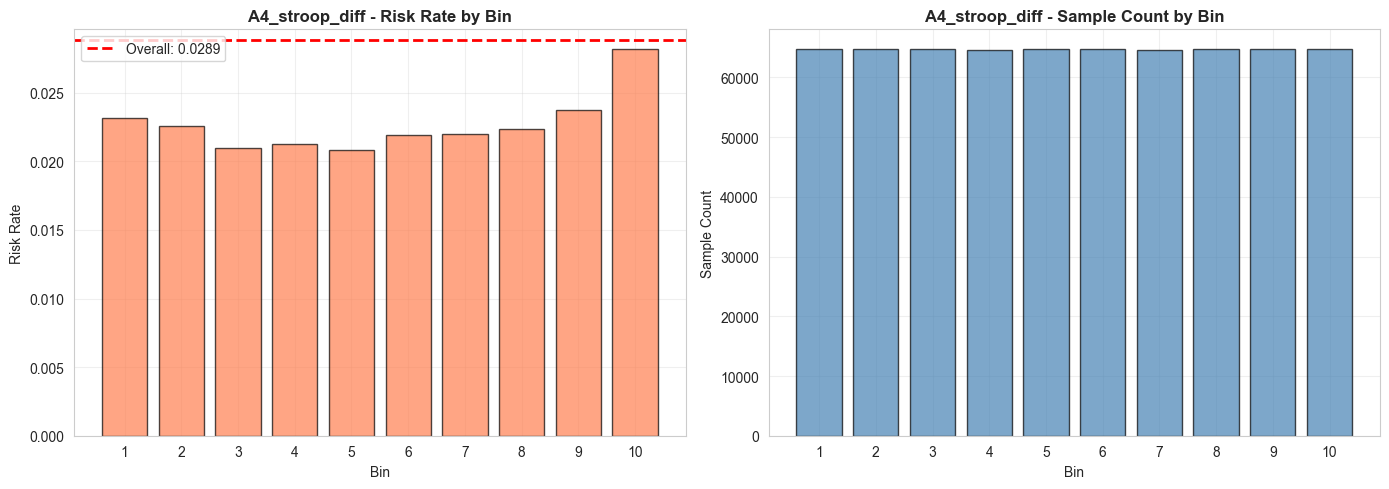

In [8]:
col = 'A4_stroop_diff'
print(f"\n{'='*80}")
print(f"[A검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(A_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.5)
    if thresholds:
        print(f"\n[Spike 구간 분석]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.4f}")
        print(f"  - High threshold: {thresholds['high_threshold']:.4f}")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

### 6.3 A1_rt_mean (반응시간)


[A검사] A1_rt_mean 구간 분석


[10분위 quantile 기준]
                   bin  risk_rate  count  coverage     left    right
0  (-727.779, -69.667]    0.02754  64823     10.02 -727.779  -69.667
1   (-69.667, -45.667]    0.02231  64734     10.00  -69.667  -45.667
2   (-45.667, -42.111]    0.02245  73310     11.33  -45.667  -42.111
3   (-42.111, -28.556]    0.02139  56141      8.67  -42.111  -28.556
4   (-28.556, -14.944]    0.02095  64833     10.02  -28.556  -14.944
5    (-14.944, -1.944]    0.02009  64562      9.97  -14.944   -1.944
6     (-1.944, 12.222]    0.02118  64674      9.99   -1.944   12.222
7     (12.222, 30.389]    0.02180  64804     10.01   12.222   30.389
8     (30.389, 53.333]    0.02195  64654      9.99   30.389   53.333
9    (53.333, 654.722]    0.02718  64706     10.00   53.333  654.722


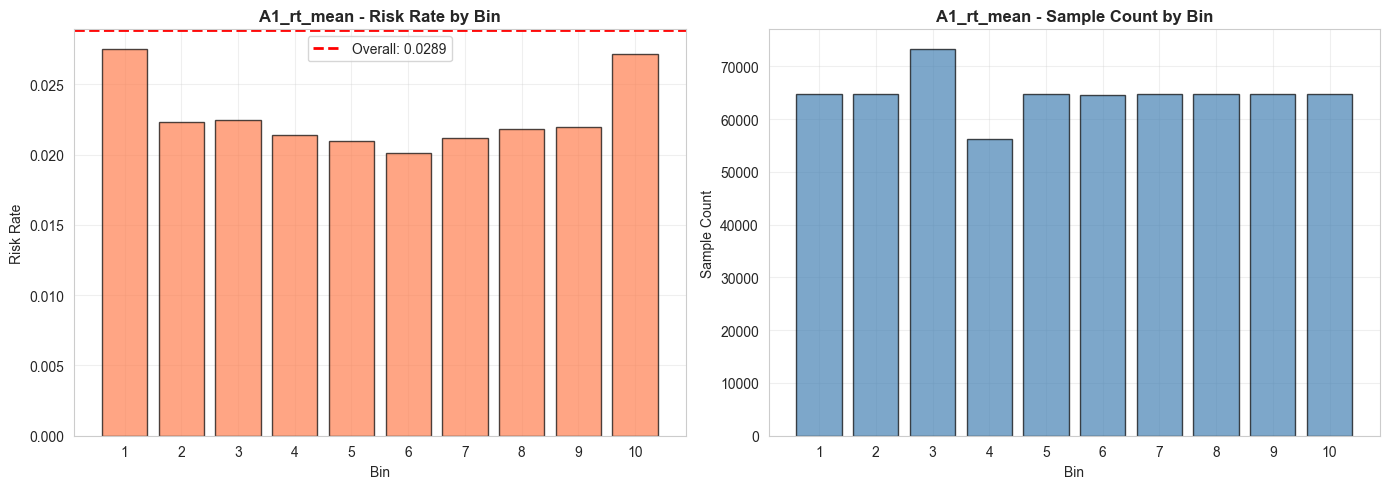

In [9]:
col = 'A1_rt_mean'
print(f"\n{'='*80}")
print(f"[A검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(A_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.3)
    if thresholds:
        print(f"\n[Spike 구간 분석]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.2f} ms")
        print(f"  - High threshold: {thresholds['high_threshold']:.2f} ms")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

### 6.4 A5_change_nonchange_gap


[A검사] A5_change_nonchange_gap 구간 분석


[10분위 quantile 기준]
              bin  risk_rate   count  coverage   left  right
0   (-1.001, 0.0]    0.02285   68744     10.62 -1.001  0.000
1    (0.0, 0.111]    0.01801   78462     12.12  0.000  0.111
2  (0.111, 0.167]    0.01911   63162      9.76  0.111  0.167
3  (0.167, 0.222]    0.02146  127236     19.66  0.167  0.222
4  (0.222, 0.278]    0.02027   68468     10.58  0.222  0.278
5  (0.278, 0.333]    0.02288   65294     10.09  0.278  0.333
6  (0.333, 0.389]    0.02494   57088      8.82  0.333  0.389
7    (0.389, 0.5]    0.02705   78329     12.10  0.389  0.500
8      (0.5, 1.0]    0.03327   40456      6.25  0.500  1.000


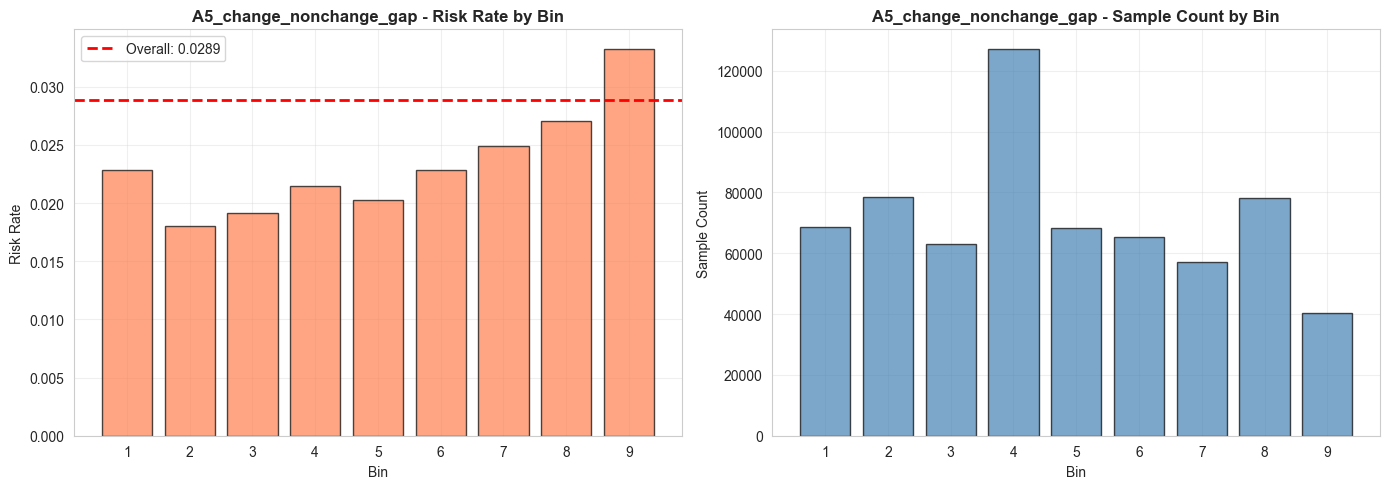

In [10]:
col = 'A5_change_nonchange_gap'
print(f"\n{'='*80}")
print(f"[A검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(A_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.5)
    if thresholds:
        print(f"\n[Spike 구간 분석]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.4f}")
        print(f"  - High threshold: {thresholds['high_threshold']:.4f}")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

### 6.5 CogScore_A (인지 점수)


[A검사] CogScore_A 구간 분석


[10분위 quantile 기준]
             bin  risk_rate  count  coverage    left right
0  (0.999, 20.0]    0.03529  78748     12.17   0.999  20.0
1   (20.0, 23.0]    0.02931  58521      9.04  20.000  23.0
2   (23.0, 26.0]    0.02508  79421     12.27  23.000  26.0
3   (26.0, 28.0]    0.02211  63595      9.83  26.000  28.0
4   (28.0, 30.0]    0.01977  67829     10.48  28.000  30.0
5   (30.0, 32.0]    0.02017  64106      9.90  30.000  32.0
6   (32.0, 34.0]    0.01874  54421      8.41  32.000  34.0
7   (34.0, 37.0]    0.01867  67182     10.38  34.000  37.0
8   (37.0, 41.0]    0.01700  58467      9.03  37.000  41.0
9   (41.0, 81.0]    0.01634  54951      8.49  41.000  81.0


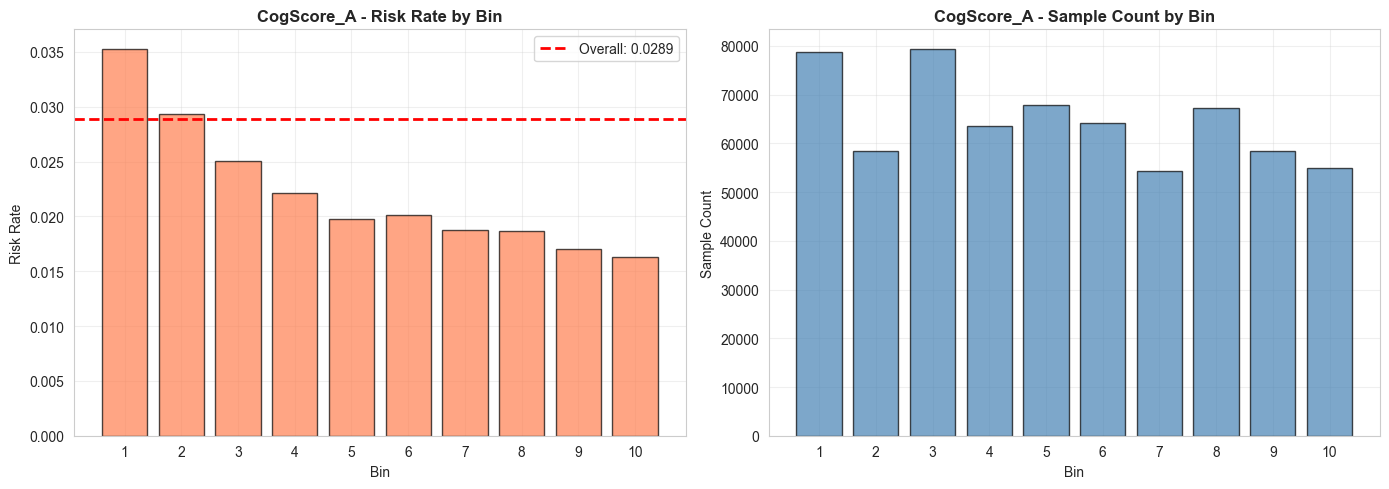


[Spike 구간 분석]
  - Low threshold: 1.00
  - High threshold: 20.00
  - Max risk rate: 0.0353


In [11]:
col = 'CogScore_A'
print(f"\n{'='*80}")
print(f"[A검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(A_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.5)
    if thresholds:
        print(f"\n[Spike 구간 분석]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.2f}")
        print(f"  - High threshold: {thresholds['high_threshold']:.2f}")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

## 7. B검사 핵심 피처 구간 분석

### 7.1 B4_acc_rate


[B검사] B4_acc_rate 구간 분석


[10분위 quantile 기준]
              bin  risk_rate   count  coverage   left  right
0  (-0.001, 0.45]    0.04288   34654     11.65 -0.001  0.450
1   (0.45, 0.483]    0.04445   65402     21.98  0.450  0.483
2    (0.483, 0.5]    0.04151  197467     66.37  0.483  0.500


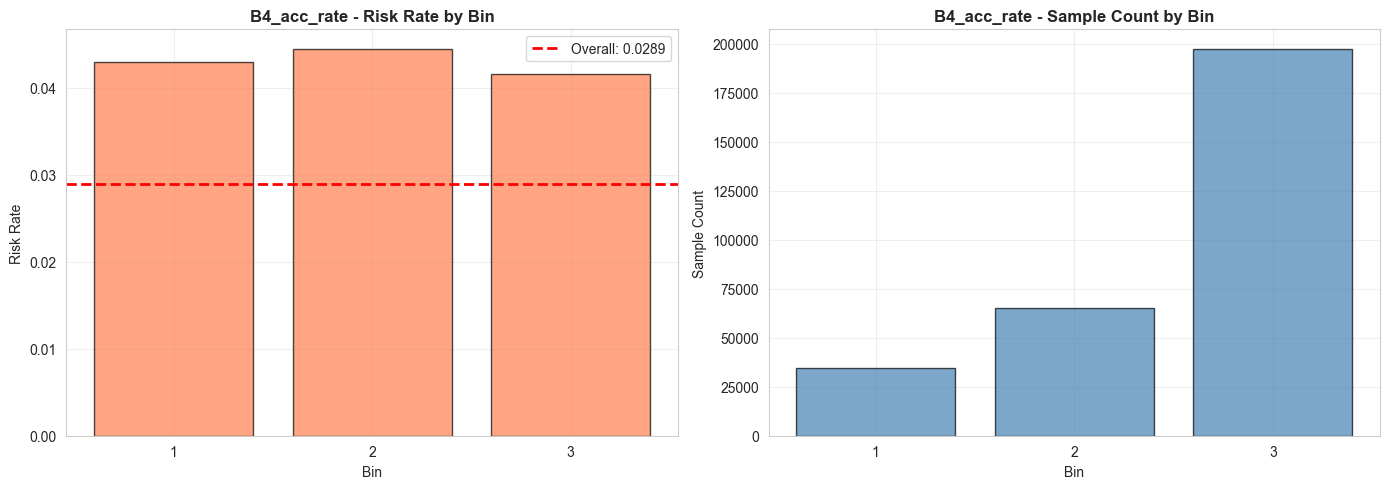

In [12]:
col = 'B4_acc_rate'
print(f"\n{'='*80}")
print(f"[B검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(B_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.3)
    if thresholds:
        print(f"\n[Spike 구간 분석]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.4f}")
        print(f"  - High threshold: {thresholds['high_threshold']:.4f}")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

### 7.2 B4_rt_mean


[B검사] B4_rt_mean 구간 분석


[10분위 quantile 기준]
              bin  risk_rate  count  coverage   left   right
0  (0.428, 0.642]    0.04286  29793     10.01  0.428   0.642
1  (0.642, 0.675]    0.04121  29801     10.02  0.642   0.675
2  (0.675, 0.701]    0.04421  29721      9.99  0.675   0.701
3  (0.701, 0.726]    0.04312  29777     10.01  0.701   0.726
4  (0.726, 0.752]    0.04148  29677      9.97  0.726   0.752
5  (0.752, 0.782]    0.04378  29782     10.01  0.752   0.782
6  (0.782, 0.817]    0.04095  29717      9.99  0.782   0.817
7  (0.817, 0.866]    0.04299  29752     10.00  0.817   0.866
8  (0.866, 0.954]    0.04059  29761     10.00  0.866   0.954
9   (0.954, 10.0]    0.04196  29742     10.00  0.954  10.000


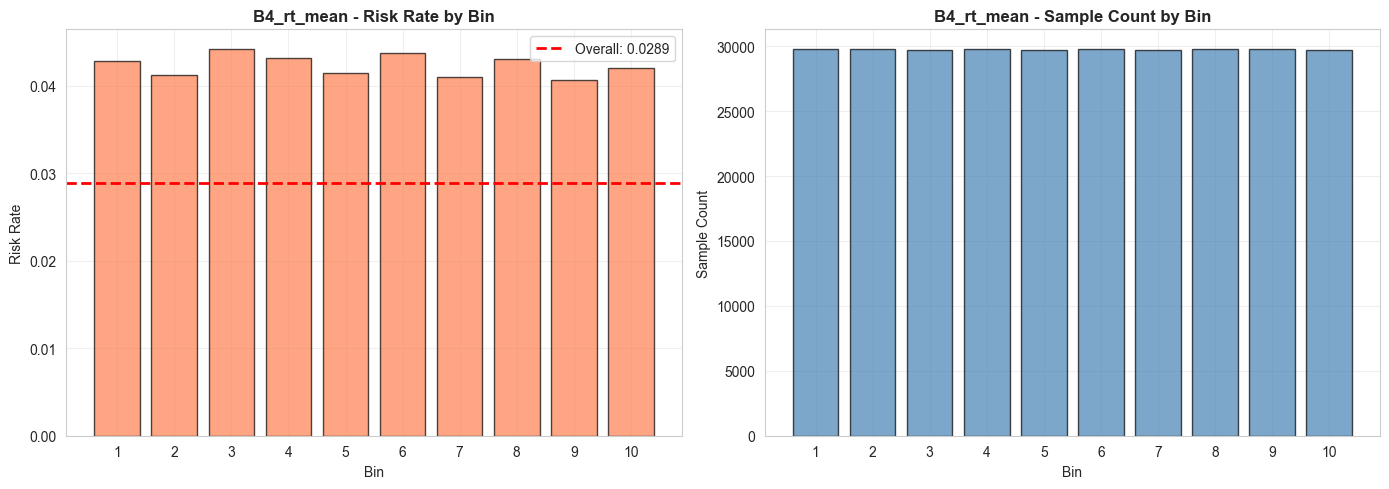

In [13]:
col = 'B4_rt_mean'
print(f"\n{'='*80}")
print(f"[B검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(B_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.3)
    if thresholds:
        print(f"\n[Spike 구간 분析]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.2f} ms")
        print(f"  - High threshold: {thresholds['high_threshold']:.2f} ms")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

### 7.3 RiskScore_B


[B검사] RiskScore_B 구간 분석


[10분위 quantile 기준]
                   bin  risk_rate  count  coverage   left        right
0       (0.218, 0.325]    0.04023  29753      10.0  0.218        0.325
1       (0.325, 0.338]    0.04171  29753      10.0  0.325        0.338
2       (0.338, 0.348]    0.04070  29752      10.0  0.338        0.348
3       (0.348, 0.358]    0.04188  29753      10.0  0.348        0.358
4       (0.358, 0.369]    0.04259  29752      10.0  0.358        0.369
5       (0.369, 0.382]    0.04423  29753      10.0  0.369        0.382
6         (0.382, 0.4]    0.04339  29752      10.0  0.382        0.400
7          (0.4, 0.43]    0.04460  29753      10.0  0.400        0.430
8        (0.43, 0.501]    0.04218  29752      10.0  0.430        0.501
9  (0.501, 2500000.78]    0.04164  29753      10.0  0.501  2500000.780


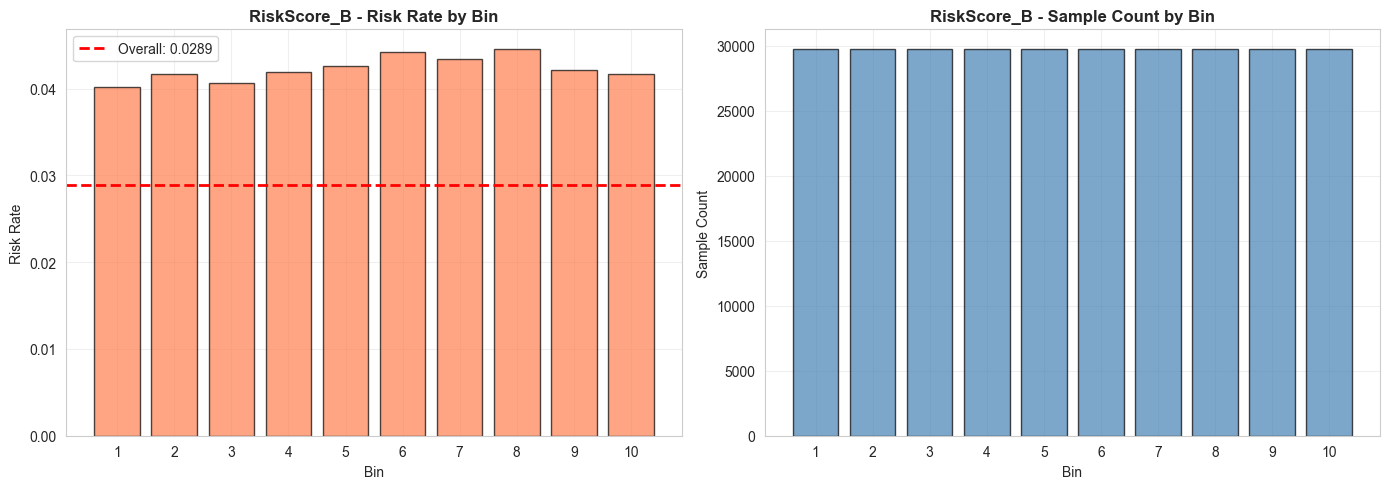

In [14]:
col = 'RiskScore_B'
print(f"\n{'='*80}")
print(f"[B검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(B_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.3)
    if thresholds:
        print(f"\n[Spike 구간 분석]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.4f}")
        print(f"  - High threshold: {thresholds['high_threshold']:.4f}")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

### 7.4 B10_multitask_cost_aud


[B검사] B10_multitask_cost_aud 구간 분석


[10분위 quantile 기준]
                 bin  risk_rate  count  coverage    left   right
0  (-0.761, -0.0875]    0.04861  31473     10.58 -0.7610 -0.0875
1   (-0.0875, -0.06]    0.04582  29310      9.85 -0.0875 -0.0600
2     (-0.06, -0.04]    0.04240  28491      9.58 -0.0600 -0.0400
3     (-0.04, -0.03]    0.04054  30411     10.22 -0.0400 -0.0300
4    (-0.03, -0.025]    0.03646  29430      9.89 -0.0300 -0.0250
5  (-0.025, -0.0125]    0.03904  42029     14.13 -0.0250 -0.0125
6     (-0.0125, 0.0]    0.03631  46242     15.54 -0.0125  0.0000
7      (0.0, 0.0025]    0.04483   3078      1.03  0.0000  0.0025
8     (0.0025, 0.04]    0.04052  28649      9.63  0.0025  0.0400
9       (0.04, 0.75]    0.05575  28413      9.55  0.0400  0.7500


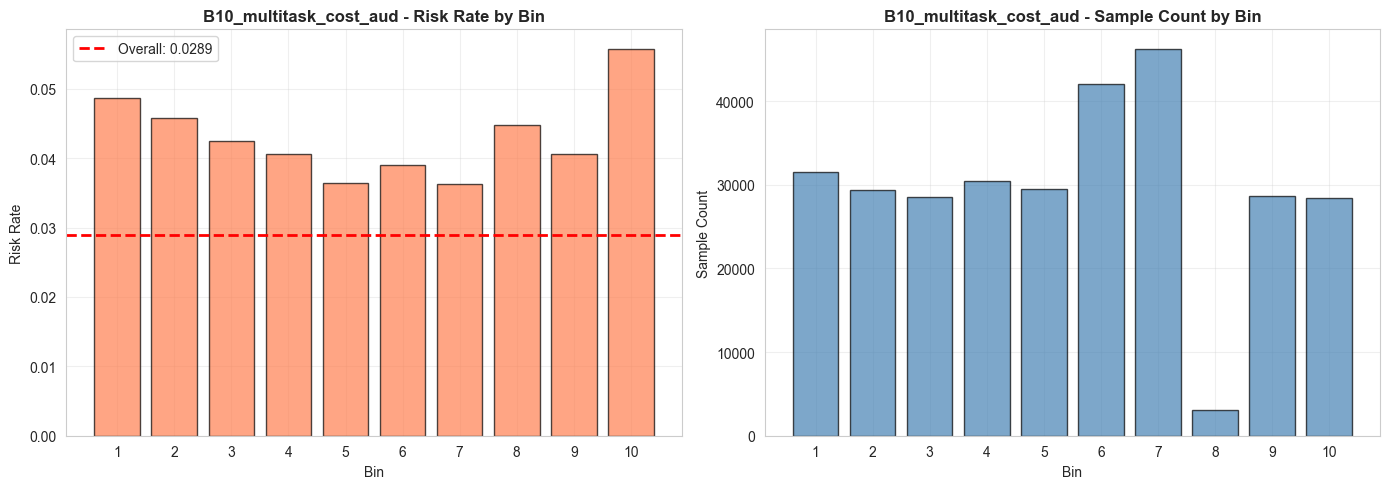

In [15]:
if 'B10_multitask_cost_aud' in B_df.columns:
    col = 'B10_multitask_cost_aud'
    print(f"\n{'='*80}")
    print(f"[B검사] {col} 구간 분석")
    print(f"{'='*80}\n")
    
    result = analyze_bins(B_df, col, bins=10, method='quantile')
    if result is not None:
        print("\n[10분위 quantile 기준]")
        print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
        plot_bin_analysis(result, col, overall_risk)
        
        thresholds = find_spike_threshold(result, spike_factor=1.3)
        if thresholds:
            print(f"\n[Spike 구간 분석]")
            print(f"  - Low threshold: {thresholds['low_threshold']:.4f}")
            print(f"  - High threshold: {thresholds['high_threshold']:.4f}")
            print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")
else:
    print("B10_multitask_cost_aud 컬럼 없음")

## 8. Indicator Feature 생성 (예시)

### 8.1 A검사 Indicator Features

In [16]:
print("\n" + "="*80)
print("[A검사] Indicator Features 생성")
print("="*80 + "\n")

# 위 분석 결과를 바탕으로 threshold 설정 (예시 - 실제 실행 후 조정 필요)
# A4_acc_rate < 0.8이면 high risk로 가정
A_df['A4_low_acc_flag'] = (A_df['A4_acc_rate'] < 0.8).astype(int)

# A4_stroop_diff > 상위 25%이면 high risk
stroop_threshold = A_df['A4_stroop_diff'].quantile(0.75)
A_df['A4_high_stroop_flag'] = (A_df['A4_stroop_diff'] > stroop_threshold).astype(int)

# A1_rt_mean > 상위 25%
rt_threshold = A_df['A1_rt_mean'].quantile(0.75)
A_df['A1_slow_rt_flag'] = (A_df['A1_rt_mean'] > rt_threshold).astype(int)

# CogScore_A < 하위 25%
cog_threshold = A_df['CogScore_A'].quantile(0.25)
A_df['A_low_cog_flag'] = (A_df['CogScore_A'] < cog_threshold).astype(int)

# 각 flag의 효과 검증
indicators_A = ['A4_low_acc_flag', 'A4_high_stroop_flag', 'A1_slow_rt_flag', 'A_low_cog_flag']

print("\n[각 Indicator의 위험비율]\n")
for ind in indicators_A:
    if ind in A_df.columns:
        risk_by_flag = A_df.groupby(ind)['Label'].agg(['mean', 'count'])
        print(f"\n{ind}:")
        print(risk_by_flag)
        print(f"  → Flag=1일 때 위험비율: {risk_by_flag.loc[1, 'mean']:.4f} (vs 전체: {overall_risk:.4f})")
        print(f"  → Flag=1 커버리지: {risk_by_flag.loc[1, 'count']} / {len(A_df)} ({risk_by_flag.loc[1, 'count']/len(A_df)*100:.2f}%)")


[A검사] Indicator Features 생성


[각 Indicator의 위험비율]


A4_low_acc_flag:
                     mean   count
A4_low_acc_flag                  
0                0.022675  646825
1                0.060096     416
  → Flag=1일 때 위험비율: 0.0601 (vs 전체: 0.0289)
  → Flag=1 커버리지: 416 / 647241 (0.06%)

A4_high_stroop_flag:
                         mean   count
A4_high_stroop_flag                  
0                    0.021820  485607
1                    0.025341  161634
  → Flag=1일 때 위험비율: 0.0253 (vs 전체: 0.0289)
  → Flag=1 커버리지: 161634 / 647241 (24.97%)

A1_slow_rt_flag:
                     mean   count
A1_slow_rt_flag                  
0                0.022288  485460
1                0.023934  161781
  → Flag=1일 때 위험비율: 0.0239 (vs 전체: 0.0289)
  → Flag=1 커버리지: 161781 / 647241 (25.00%)

A_low_cog_flag:
                    mean   count
A_low_cog_flag                  
0               0.019613  485890
1               0.031992  161351
  → Flag=1일 때 위험비율: 0.0320 (vs 전체: 0.0289)
  → Flag=1 커버리지: 161351

### 8.2 B검사 Indicator Features

In [17]:
print("\n" + "="*80)
print("[B검사] Indicator Features 생성")
print("="*80 + "\n")

# B4_acc_rate < 0.85
B_df['B4_low_acc_flag'] = (B_df['B4_acc_rate'] < 0.85).astype(int)

# B4_rt_mean > 상위 25%
b4_rt_threshold = B_df['B4_rt_mean'].quantile(0.75)
B_df['B4_slow_rt_flag'] = (B_df['B4_rt_mean'] > b4_rt_threshold).astype(int)

# RiskScore_B > 상위 25%
risk_threshold = B_df['RiskScore_B'].quantile(0.75)
B_df['B_high_risk_flag'] = (B_df['RiskScore_B'] > risk_threshold).astype(int)

indicators_B = ['B4_low_acc_flag', 'B4_slow_rt_flag', 'B_high_risk_flag']

print("\n[각 Indicator의 위험비율]\n")
for ind in indicators_B:
    if ind in B_df.columns:
        risk_by_flag = B_df.groupby(ind)['Label'].agg(['mean', 'count'])
        print(f"\n{ind}:")
        print(risk_by_flag)
        if 1 in risk_by_flag.index:
            print(f"  → Flag=1일 때 위험비율: {risk_by_flag.loc[1, 'mean']:.4f} (vs 전체: {overall_risk:.4f})")
            print(f"  → Flag=1 커버리지: {risk_by_flag.loc[1, 'count']} / {len(B_df)} ({risk_by_flag.loc[1, 'count']/len(B_df)*100:.2f}%)")


[B검사] Indicator Features 생성


[각 Indicator의 위험비율]


B4_low_acc_flag:
                     mean   count
B4_low_acc_flag                  
0                0.000000       3
1                0.042316  297523
  → Flag=1일 때 위험비율: 0.0423 (vs 전체: 0.0289)
  → Flag=1 커버리지: 297523 / 297526 (100.00%)

B4_slow_rt_flag:
                     mean   count
B4_slow_rt_flag                  
0                0.042531  223154
1                0.041669   74372
  → Flag=1일 때 위험비율: 0.0417 (vs 전체: 0.0289)
  → Flag=1 커버리지: 74372 / 297526 (25.00%)

B_high_risk_flag:
                      mean   count
B_high_risk_flag                  
0                 0.042233  223144
1                 0.042564   74382
  → Flag=1일 때 위험비율: 0.0426 (vs 전체: 0.0289)
  → Flag=1 커버리지: 74382 / 297526 (25.00%)


## 9. Age 복합 조건 분석

### 9.1 Age bin 정의

In [18]:
def age_bin(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 50:
        return '<50'
    elif age < 60:
        return '50-59'
    else:
        return '60+'

A_df['Age_bin'] = A_df['Age_num'].apply(age_bin)
B_df['Age_bin'] = B_df['Age_num'].apply(age_bin)

print("Age bin 생성 완료")

Age bin 생성 완료


### 9.2 A검사: Age × Indicator 교차 분석

In [19]:
print("\n" + "="*80)
print("[A검사] Age × Indicator 교차 분석")
print("="*80 + "\n")

# Age_bin × A4_low_acc_flag
if 'A4_low_acc_flag' in A_df.columns:
    print("\n[Age_bin × A4_low_acc_flag]\n")
    cross = pd.crosstab(
        A_df['Age_bin'], 
        A_df['A4_low_acc_flag'],
        A_df['Label'],
        aggfunc='mean',
        margins=True
    )
    print("위험비율:")
    print(cross.round(4))
    
    count = pd.crosstab(
        A_df['Age_bin'],
        A_df['A4_low_acc_flag'],
        margins=True
    )
    print("\n샘플 수:")
    print(count)
    
    # 복합 조건 만들기
    A_df['Old_and_low_A4'] = (
        (A_df['Age_num'] >= 60) & (A_df['A4_low_acc_flag'] == 1)
    ).astype(int)
    
    print("\n[복합 조건: Old_and_low_A4 (Age>=60 & A4_low_acc)]")
    complex_risk = A_df.groupby('Old_and_low_A4')['Label'].agg(['mean', 'count'])
    print(complex_risk)
    if 1 in complex_risk.index:
        print(f"  → 복합조건 만족 시 위험비율: {complex_risk.loc[1, 'mean']:.4f}")
        print(f"  → 전체 대비 증가: {(complex_risk.loc[1, 'mean'] / overall_risk - 1) * 100:.1f}%")


[A검사] Age × Indicator 교차 분석


[Age_bin × A4_low_acc_flag]

위험비율:
A4_low_acc_flag       0       1     All
Age_bin                                
50-59            0.0226  0.0370  0.0226
60+              0.0555  0.0922  0.0555
<50              0.0137  0.0133  0.0137
All              0.0227  0.0601  0.0227

샘플 수:
A4_low_acc_flag       0    1     All
Age_bin                             
50-59            189866  135  190001
60+               98538  206   98744
<50              358421   75  358496
All              646825  416  647241

[복합 조건: Old_and_low_A4 (Age>=60 & A4_low_acc)]
                    mean   count
Old_and_low_A4                  
0               0.022677  647035
1               0.092233     206
  → 복합조건 만족 시 위험비율: 0.0922
  → 전체 대비 증가: 219.4%


### 9.3 B검사: Age × Indicator 교차 분석

In [20]:
print("\n" + "="*80)
print("[B검사] Age × Indicator 교차 분석")
print("="*80 + "\n")

# Age_bin × B4_low_acc_flag
if 'B4_low_acc_flag' in B_df.columns:
    print("\n[Age_bin × B4_low_acc_flag]\n")
    cross = pd.crosstab(
        B_df['Age_bin'],
        B_df['B4_low_acc_flag'],
        B_df['Label'],
        aggfunc='mean',
        margins=True
    )
    print("위험비율:")
    print(cross.round(4))
    
    count = pd.crosstab(
        B_df['Age_bin'],
        B_df['B4_low_acc_flag'],
        margins=True
    )
    print("\n샘플 수:")
    print(count)
    
    # 복합 조건
    B_df['Old_and_low_B4'] = (
        (B_df['Age_num'] >= 60) & (B_df['B4_low_acc_flag'] == 1)
    ).astype(int)
    
    print("\n[복합 조건: Old_and_low_B4 (Age>=60 & B4_low_acc)]")
    complex_risk = B_df.groupby('Old_and_low_B4')['Label'].agg(['mean', 'count'])
    print(complex_risk)
    if 1 in complex_risk.index:
        print(f"  → 복합조건 만족 시 위험비율: {complex_risk.loc[1, 'mean']:.4f}")
        print(f"  → 전체 대비 증가: {(complex_risk.loc[1, 'mean'] / overall_risk - 1) * 100:.1f}%")


[B검사] Age × Indicator 교차 분석


[Age_bin × B4_low_acc_flag]

위험비율:
B4_low_acc_flag    0       1     All
Age_bin                             
60+              0.0  0.0423  0.0423
All              0.0  0.0423  0.0423

샘플 수:
B4_low_acc_flag  0       1     All
Age_bin                           
60+              3  297523  297526
All              3  297523  297526

[복합 조건: Old_and_low_B4 (Age>=60 & B4_low_acc)]
                    mean   count
Old_and_low_B4                  
0               0.000000       3
1               0.042316  297523
  → 복합조건 만족 시 위험비율: 0.0423
  → 전체 대비 증가: 46.5%


## 10. Age 인터랙션 피처 생성

In [21]:
print("\n" + "="*80)
print("Age 인터랙션 피처 생성")
print("="*80 + "\n")

# A검사
print("[A검사 인터랙션]")
A_df['Age_x_A4_stroop'] = A_df['Age_num'] * A_df['A4_stroop_diff']
A_df['Age_x_A4_acc_inv'] = A_df['Age_num'] * (1 - A_df['A4_acc_rate'].fillna(0))
A_df['Age_x_A5_gap'] = A_df['Age_num'] * A_df['A5_change_nonchange_gap']
A_df['Age_x_CogScore'] = A_df['Age_num'] * A_df['CogScore_A']

age_interactions_A = ['Age_x_A4_stroop', 'Age_x_A4_acc_inv', 'Age_x_A5_gap', 'Age_x_CogScore']
for feat in age_interactions_A:
    if feat in A_df.columns:
        corr = A_df[['Label', feat]].corr().loc['Label', feat]
        print(f"  {feat}: Label 상관 = {corr:.5f}")

# B검사
print("\n[B검사 인터랙션]")
B_df['Age_x_B4_acc_inv'] = B_df['Age_num'] * (1 - B_df['B4_acc_rate'].fillna(0))
B_df['Age_x_B4_rt'] = B_df['Age_num'] * B_df['B4_rt_mean']
B_df['Age_x_RiskScore'] = B_df['Age_num'] * B_df['RiskScore_B']
if 'B10_multitask_cost_aud' in B_df.columns:
    B_df['Age_x_B10_multitask'] = B_df['Age_num'] * B_df['B10_multitask_cost_aud']

age_interactions_B = ['Age_x_B4_acc_inv', 'Age_x_B4_rt', 'Age_x_RiskScore']
if 'Age_x_B10_multitask' in B_df.columns:
    age_interactions_B.append('Age_x_B10_multitask')

for feat in age_interactions_B:
    if feat in B_df.columns:
        corr = B_df[['Label', feat]].corr().loc['Label', feat]
        print(f"  {feat}: Label 상관 = {corr:.5f}")

print("\nAge 인터랙션 피처 생성 완료!")


Age 인터랙션 피처 생성

[A검사 인터랙션]
  Age_x_A4_stroop: Label 상관 = 0.01778
  Age_x_A4_acc_inv: Label 상관 = 0.02582
  Age_x_A5_gap: Label 상관 = 0.03155
  Age_x_CogScore: Label 상관 = 0.02334

[B검사 인터랙션]
  Age_x_B4_acc_inv: Label 상관 = -0.00014
  Age_x_B4_rt: Label 상관 = -0.00152
  Age_x_RiskScore: Label 상관 = -0.00167
  Age_x_B10_multitask: Label 상관 = 0.00017

Age 인터랙션 피처 생성 완료!


## 11. 최종 피처 리스트 및 script04 통합 코드

In [22]:
print("\n" + "="*80)
print("최종 추가 피처 리스트")
print("="*80 + "\n")

print("[A검사 추가 피처]")
print("""
1. Age 관련:
   - Age_bin (더미 변수로 변환)
   - Age_z

2. Indicator Features:
   - A4_low_acc_flag
   - A4_high_stroop_flag
   - A1_slow_rt_flag
   - A_low_cog_flag

3. 복합 조건:
   - Old_and_low_A4

4. Age 인터랙션:
   - Age_x_A4_stroop
   - Age_x_A4_acc_inv
   - Age_x_A5_gap
   - Age_x_CogScore

5. 기존 피처 유지:
   - CogScore_A, EmoScore_A
   - A5_change_nonchange_gap
""")

print("\n[B검사 추가 피처]")
print("""
1. Age 관련:
   - Age_bin (더미 변수로 변환)
   - Age_z

2. Indicator Features:
   - B4_low_acc_flag
   - B4_slow_rt_flag
   - B_high_risk_flag

3. 복합 조건:
   - Old_and_low_B4

4. Age 인터랙션:
   - Age_x_B4_acc_inv
   - Age_x_B4_rt
   - Age_x_RiskScore
   - Age_x_B10_multitask (if available)

5. 기존 피처 유지:
   - RiskScore_B
   - B10_multitask_cost_aud/vis
""")


최종 추가 피처 리스트

[A검사 추가 피처]

1. Age 관련:
   - Age_bin (더미 변수로 변환)
   - Age_z

2. Indicator Features:
   - A4_low_acc_flag
   - A4_high_stroop_flag
   - A1_slow_rt_flag
   - A_low_cog_flag

3. 복합 조건:
   - Old_and_low_A4

4. Age 인터랙션:
   - Age_x_A4_stroop
   - Age_x_A4_acc_inv
   - Age_x_A5_gap
   - Age_x_CogScore

5. 기존 피처 유지:
   - CogScore_A, EmoScore_A
   - A5_change_nonchange_gap


[B검사 추가 피처]

1. Age 관련:
   - Age_bin (더미 변수로 변환)
   - Age_z

2. Indicator Features:
   - B4_low_acc_flag
   - B4_slow_rt_flag
   - B_high_risk_flag

3. 복합 조건:
   - Old_and_low_B4

4. Age 인터랙션:
   - Age_x_B4_acc_inv
   - Age_x_B4_rt
   - Age_x_RiskScore
   - Age_x_B10_multitask (if available)

5. 기존 피처 유지:
   - RiskScore_B
   - B10_multitask_cost_aud/vis



### 11.1 script04.py 통합 코드 (복사용)

In [23]:
print("""
# ============================================================
# script04.py의 add_features_A()에 추가할 코드
# ============================================================

def add_features_A(df: pd.DataFrame) -> pd.DataFrame:
    feats = df.copy()
    eps = 1e-6
    
    # ... (기존 코드)
    
    # ===== 새로 추가 =====
    
    # 1. Age_z
    if 'Age_num' in feats.columns:
        age_mean = feats['Age_num'].mean()
        age_std = feats['Age_num'].std()
        feats['Age_z'] = (feats['Age_num'] - age_mean) / (age_std + eps)
    
    # 2. Indicator flags (threshold는 분석 결과 기반 조정)
    if 'A4_acc_rate' in feats.columns:
        feats['A4_low_acc_flag'] = (feats['A4_acc_rate'] < 0.8).astype(int)
    
    if 'A4_stroop_diff' in feats.columns:
        stroop_threshold = feats['A4_stroop_diff'].quantile(0.75)
        feats['A4_high_stroop_flag'] = (feats['A4_stroop_diff'] > stroop_threshold).astype(int)
    
    if 'A1_rt_mean' in feats.columns:
        rt_threshold = feats['A1_rt_mean'].quantile(0.75)
        feats['A1_slow_rt_flag'] = (feats['A1_rt_mean'] > rt_threshold).astype(int)
    
    # 3. Age 인터랙션 (기존 Age_x_A1_RT 외 추가)
    if _has(feats, ['Age_num', 'A4_stroop_diff']):
        feats['Age_x_A4_stroop'] = feats['Age_num'] * feats['A4_stroop_diff']
    
    if _has(feats, ['Age_num', 'A4_acc_rate']):
        feats['Age_x_A4_acc_inv'] = feats['Age_num'] * (1 - feats['A4_acc_rate'].fillna(0))
    
    if _has(feats, ['Age_num', 'A5_change_nonchange_gap']):
        feats['Age_x_A5_gap'] = feats['Age_num'] * feats['A5_change_nonchange_gap']
    
    # 4. 복합 조건
    if _has(feats, ['Age_num', 'A4_low_acc_flag']):
        feats['Old_and_low_A4'] = (
            (feats['Age_num'] >= 60) & (feats['A4_low_acc_flag'] == 1)
        ).astype(int)
    
    feats.replace([np.inf, -np.inf], np.nan, inplace=True)
    return feats

# ============================================================
# script04.py의 add_features_B()에 추가할 코드
# ============================================================

def add_features_B(df: pd.DataFrame) -> pd.DataFrame:
    feats = df.copy()
    eps = 1e-6
    
    # ... (기존 코드)
    
    # ===== 새로 추가 =====
    
    # 1. Age_z
    if 'Age_num' in feats.columns:
        age_mean = feats['Age_num'].mean()
        age_std = feats['Age_num'].std()
        feats['Age_z'] = (feats['Age_num'] - age_mean) / (age_std + eps)
    
    # 2. Indicator flags
    if 'B4_acc_rate' in feats.columns:
        feats['B4_low_acc_flag'] = (feats['B4_acc_rate'] < 0.85).astype(int)
    
    if 'B4_rt_mean' in feats.columns:
        b4_rt_threshold = feats['B4_rt_mean'].quantile(0.75)
        feats['B4_slow_rt_flag'] = (feats['B4_rt_mean'] > b4_rt_threshold).astype(int)
    
    if 'RiskScore_B' in feats.columns:
        risk_threshold = feats['RiskScore_B'].quantile(0.75)
        feats['B_high_risk_flag'] = (feats['RiskScore_B'] > risk_threshold).astype(int)
    
    # 3. Age 인터랙션
    if _has(feats, ['Age_num', 'B4_acc_rate']):
        feats['Age_x_B4_acc_inv'] = feats['Age_num'] * (1 - feats['B4_acc_rate'].fillna(0))
    
    if _has(feats, ['Age_num', 'B4_rt_mean']):
        feats['Age_x_B4_rt'] = feats['Age_num'] * feats['B4_rt_mean']
    
    if _has(feats, ['Age_num', 'RiskScore_B']):
        feats['Age_x_RiskScore'] = feats['Age_num'] * feats['RiskScore_B']
    
    if _has(feats, ['Age_num', 'B10_multitask_cost_aud']):
        feats['Age_x_B10_multitask'] = feats['Age_num'] * feats['B10_multitask_cost_aud']
    
    # 4. 복합 조건
    if _has(feats, ['Age_num', 'B4_low_acc_flag']):
        feats['Old_and_low_B4'] = (
            (feats['Age_num'] >= 60) & (feats['B4_low_acc_flag'] == 1)
        ).astype(int)
    
    feats.replace([np.inf, -np.inf], np.nan, inplace=True)
    return feats
""")


# ============================================================
# script04.py의 add_features_A()에 추가할 코드
# ============================================================

def add_features_A(df: pd.DataFrame) -> pd.DataFrame:
    feats = df.copy()
    eps = 1e-6
    
    # ... (기존 코드)
    
    # ===== 새로 추가 =====
    
    # 1. Age_z
    if 'Age_num' in feats.columns:
        age_mean = feats['Age_num'].mean()
        age_std = feats['Age_num'].std()
        feats['Age_z'] = (feats['Age_num'] - age_mean) / (age_std + eps)
    
    # 2. Indicator flags (threshold는 분석 결과 기반 조정)
    if 'A4_acc_rate' in feats.columns:
        feats['A4_low_acc_flag'] = (feats['A4_acc_rate'] < 0.8).astype(int)
    
    if 'A4_stroop_diff' in feats.columns:
        stroop_threshold = feats['A4_stroop_diff'].quantile(0.75)
        feats['A4_high_stroop_flag'] = (feats['A4_stroop_diff'] > stroop_threshold).astype(int)
    
    if 'A1_rt_mean' in feats.columns:
        rt_threshold = feats['A1_rt_mean'].quantile(0.7

## 12. 요약

In [24]:
print("\n" + "="*80)
print("분석 완료 요약")
print("="*80 + "\n")

print("""
✅ 완료한 작업:

1. 핵심 피처별 구간 분석 (10분위 quantile)
   - 위험비율이 튀는 구간 식별
   - Threshold 자동 탐지 (spike_factor 활용)

2. Indicator Feature 생성
   - A검사: A4_low_acc_flag, A4_high_stroop_flag, A1_slow_rt_flag 등
   - B검사: B4_low_acc_flag, B4_slow_rt_flag, B_high_risk_flag 등
   - 각 flag의 효과 검증 (위험비율, 커버리지)

3. Age 복합 조건
   - Age_bin × Indicator 교차 분석
   - Old_and_low_A4, Old_and_low_B4 등 복합 flag 생성

4. Age 인터랙션 피처
   - Age × 핵심 점수 (stroop, acc, RiskScore 등)
   - Label과의 상관계수 확인

📋 다음 단계:

1. 이 노트북 실행 후 실제 threshold 값 확인
2. 위 코드를 script04.py에 통합
3. 모델 재학습 및 Holdout AUC 비교
   - A 검사: 기존 AUC vs 새 피처 AUC
   - B 검사: 0.59 → 0.60+ 목표
4. Feature importance 확인 후 불필요한 피처 제거
5. 최종 제출

💡 핵심 인사이트:
- 구간별 위험비율을 보면 "어디서 튀는지" 명확히 보임
- Indicator feature는 모델이 비선형 패턴을 더 쉽게 학습하도록 도움
- Age는 단독보다는 성능 지표와 조합할 때 더 강력
""")

print("\n🎉 분석 완료!")


분석 완료 요약


✅ 완료한 작업:

1. 핵심 피처별 구간 분석 (10분위 quantile)
   - 위험비율이 튀는 구간 식별
   - Threshold 자동 탐지 (spike_factor 활용)

2. Indicator Feature 생성
   - A검사: A4_low_acc_flag, A4_high_stroop_flag, A1_slow_rt_flag 등
   - B검사: B4_low_acc_flag, B4_slow_rt_flag, B_high_risk_flag 등
   - 각 flag의 효과 검증 (위험비율, 커버리지)

3. Age 복합 조건
   - Age_bin × Indicator 교차 분석
   - Old_and_low_A4, Old_and_low_B4 등 복합 flag 생성

4. Age 인터랙션 피처
   - Age × 핵심 점수 (stroop, acc, RiskScore 등)
   - Label과의 상관계수 확인

📋 다음 단계:

1. 이 노트북 실행 후 실제 threshold 값 확인
2. 위 코드를 script04.py에 통합
3. 모델 재학습 및 Holdout AUC 비교
   - A 검사: 기존 AUC vs 새 피처 AUC
   - B 검사: 0.59 → 0.60+ 목표
4. Feature importance 확인 후 불필요한 피처 제거
5. 최종 제출

💡 핵심 인사이트:
- 구간별 위험비율을 보면 "어디서 튀는지" 명확히 보임
- Indicator feature는 모델이 비선형 패턴을 더 쉽게 학습하도록 도움
- Age는 단독보다는 성능 지표와 조합할 때 더 강력


🎉 분석 완료!


In [25]:
# 최종 생성된 피처 데이터 저장
import os

# 출력 디렉토리 생성
os.makedirs('output', exist_ok=True)

print("="*80)
print("피처 데이터 저장")
print("="*80 + "\n")

# A검사 데이터 저장
a_output_path = 'output/A_features_final.parquet'
A_df.to_parquet(a_output_path, index=False)
print(f"✅ A검사 데이터 저장 완료: {a_output_path}")
print(f"   Shape: {A_df.shape}")
print(f"   메모리 사용량: {A_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# B검사 데이터 저장
b_output_path = 'output/B_features_final.parquet'
B_df.to_parquet(b_output_path, index=False)
print(f"\n✅ B검사 데이터 저장 완료: {b_output_path}")
print(f"   Shape: {B_df.shape}")
print(f"   메모리 사용량: {B_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n📁 저장 위치: {os.path.abspath('output')}")

# 주요 피처 컬럼만 CSV로도 저장 (확인용)
key_cols_A = ['Test_id', 'PrimaryKey', 'Label', 'Age_num', 
              'A4_acc_rate', 'A4_stroop_diff', 'A1_rt_mean', 
              'A1_rt_trend', 'A4_rt_trend',
              'test_count', 'days_since_first',
              'Old_and_low_A4',
              'A8_invalid_response_flag', 'Invalid_and_Stressed']
key_cols_A = [c for c in key_cols_A if c in A_df.columns]

key_cols_B = ['Test_id', 'PrimaryKey', 'Label', 'Age_num',
              'B4_acc_rate', 'B3_rt_mean', 'RiskScore_B',
              'B9_hit_rate', 'B9_dprime', 'B10_hit_rate', 'B10_dprime',
              'B3_rt_trend', 'test_count', 'days_since_first',
              'B1_acc_rate', 'B5_acc_rate',
              'Old_and_low_B1', 'Old_and_low_B3', 'Old_and_low_B5']
key_cols_B = [c for c in key_cols_B if c in B_df.columns]

A_df[key_cols_A].head(1000).to_csv('output/A_features_sample.csv', index=False)
B_df[key_cols_B].head(1000).to_csv('output/B_features_sample.csv', index=False)
print(f"\n✅ 샘플 CSV 저장 완료 (확인용, 1000행)")
print(f"   - output/A_features_sample.csv")
print(f"   - output/B_features_sample.csv")

# 피처 목록 저장 (문서화)
print(f"\n📝 피처 목록 저장 중...")

with open('output/feature_list.txt', 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("A검사 피처 목록\n")
    f.write("="*80 + "\n\n")
    
    # 메타 컬럼 제외
    meta_cols = ['Test_id', 'PrimaryKey', 'Age', 'TestDate', 'Test', 'Label']
    a_features = [c for c in A_df.columns if c not in meta_cols and not c.startswith('A1-') and not c.startswith('A2-') and not c.startswith('A3-') and not c.startswith('A4-') and not c.startswith('A5-') and not c.startswith('A6-') and not c.startswith('A7-') and not c.startswith('A8-') and not c.startswith('A9-')]
    
    for i, feat in enumerate(sorted(a_features), 1):
        f.write(f"{i:3d}. {feat}\n")
    
    f.write(f"\n총 {len(a_features)}개 피처\n\n")
    
    f.write("="*80 + "\n")
    f.write("B검사 피처 목록\n")
    f.write("="*80 + "\n\n")
    
    b_features = [c for c in B_df.columns if c not in meta_cols and not c.startswith('B1-') and not c.startswith('B2-') and not c.startswith('B3-') and not c.startswith('B4-') and not c.startswith('B5-') and not c.startswith('B6') and not c.startswith('B7') and not c.startswith('B8') and not c.startswith('B9-') and not c.startswith('B10-')]
    
    for i, feat in enumerate(sorted(b_features), 1):
        f.write(f"{i:3d}. {feat}\n")
    
    f.write(f"\n총 {len(b_features)}개 피처\n")

print(f"✅ 피처 목록 저장 완료: output/feature_list.txt")

print("\n" + "="*80)
print("🎉 모든 작업 완료!")
print("="*80)
print(f"""
저장된 파일:
  1. output/A_features_final.parquet ({A_df.shape[0]:,}행 × {A_df.shape[1]}열)
  2. output/B_features_final.parquet ({B_df.shape[0]:,}행 × {B_df.shape[1]}열)
  3. output/A_features_sample.csv (확인용)
  4. output/B_features_sample.csv (확인용)
  5. output/feature_list.txt (피처 목록)

다음 단계:
  1. Parquet 파일을 모델 학습 스크립트에서 로드
  2. HistGradientBoosting으로 학습
  3. Feature importance 확인
  4. Holdout AUC 검증
""")

피처 데이터 저장

✅ A검사 데이터 저장 완료: output/A_features_final.parquet
   Shape: (647241, 66)
   메모리 사용량: 2515.58 MB

✅ B검사 데이터 저장 완료: output/B_features_final.parquet
   Shape: (297526, 59)
   메모리 사용량: 757.09 MB

📁 저장 위치: c:\Users\표서연\open_v2\output

✅ 샘플 CSV 저장 완료 (확인용, 1000행)
   - output/A_features_sample.csv
   - output/B_features_sample.csv

📝 피처 목록 저장 중...
✅ 피처 목록 저장 완료: output/feature_list.txt

🎉 모든 작업 완료!

저장된 파일:
  1. output/A_features_final.parquet (647,241행 × 66열)
  2. output/B_features_final.parquet (297,526행 × 59열)
  3. output/A_features_sample.csv (확인용)
  4. output/B_features_sample.csv (확인용)
  5. output/feature_list.txt (피처 목록)

다음 단계:
  1. Parquet 파일을 모델 학습 스크립트에서 로드
  2. HistGradientBoosting으로 학습
  3. Feature importance 확인
  4. Holdout AUC 검증



## 22. 최종 피처 데이터 저장

In [26]:
print("\n" + "="*80)
print("최종 피처 리스트 및 요약 (전체 업데이트)")
print("="*80 + "\n")

print("✅ 생성 완료된 모든 피처 그룹:\n")

print("=" * 80)
print("[A검사 피처]")
print("=" * 80)
print("""
1. 기본 피처:
   - Age_num, Age_z, Age_bin
   - A1_resp_rate, A1_rt_mean, A1_rt_std, A1_rt_cv
   - A4_acc_rate, A4_rt_mean, A4_stroop_diff
   - A5_acc_rate, A5_change_nonchange_gap
   - CogScore_A, EmoScore_A

2. Indicator Features (구간 기반):
   - A4_low_acc_flag
   - A4_high_stroop_flag
   - A1_slow_rt_flag
   - A_low_cog_flag

3. Age 인터랙션:
   - Age_x_A4_stroop
   - Age_x_A4_acc_inv
   - Age_x_A5_gap
   - Age_x_CogScore

4. 복합 조건:
   - Old_and_low_A4

5. 시퀀스 패턴:
   - A1_rt_trend, A1_rt_fatigue, A1_rt_outlier_ratio, A1_rt_cv_pattern
   - A4_rt_trend, A4_rt_fatigue, A4_rt_outlier_ratio, A4_rt_cv_pattern

6. A9 하위 척도:
   - A9-1 ~ A9-5 개별 점수
   - 가장 효과적인 척도의 high/low flag

7. 시계열 피처:
   - test_count, days_since_first, test_interval_mean
   - A4_acc_rate_change_from_first, A4_acc_rate_change_from_prev
   - A1_rt_mean_change_from_first, A1_rt_mean_change_from_prev
   - CogScore_A_change_from_first, CogScore_A_change_from_prev

8. A8 타당도 척도 (NEW! 사용자 제안):
   - A8_high_distortion_flag (응답 왜곡 상위 10%)
   - A8_low_consistency_flag (반응 일관성 하위 10%)
   - A8_invalid_response_flag (복합 조건)
   - Invalid_and_Stressed (불성실 × 스트레스)
   - A9_high_stress_flag
""")

print("\n" + "=" * 80)
print("[B검사 피처]")
print("=" * 80)
print("""
1. 기본 피처:
   - Age_num, Age_z, Age_bin
   - B3_acc_rate, B3_rt_mean, B3_rt_std
   - B4_acc_rate, B4_rt_mean, B4_rt_std
   - RiskScore_B
   - B9_aud_overall_acc, B9_vis_err_rate
   - B10_aud_overall_acc, B10_vis1_err_rate
   - B10_multitask_cost_aud, B10_multitask_cost_vis

2. Indicator Features:
   - B4_low_acc_flag
   - B4_slow_rt_flag
   - B_high_risk_flag

3. Age 인터랙션:
   - Age_x_B4_acc_inv
   - Age_x_B4_rt
   - Age_x_RiskScore
   - Age_x_B10_multitask

4. 복합 조건:
   - Old_and_low_B4

5. 시퀀스 패턴:
   - B3_rt_trend, B3_rt_fatigue, B3_rt_outlier_ratio, B3_rt_cv_pattern

6. Aud/Vis 세부 분석:
   - B9_hit_rate, B9_fa_rate, B9_cr_rate, B9_dprime, B9_criterion
   - B10_hit_rate, B10_fa_rate, B10_cr_rate, B10_dprime, B10_criterion
   - B10_B9_hit_degradation, B10_B9_dprime_degradation, B10_B9_fa_increase
   - B9_vis_err_normalized, B10_vis1_err_normalized, B10_B9_vis_err_increase

7. 시계열 피처:
   - test_count, days_since_first, test_interval_mean
   - B4_acc_rate_change_from_first, B4_acc_rate_change_from_prev
   - B3_rt_mean_change_from_first, B3_rt_mean_change_from_prev
   - RiskScore_B_change_from_first, RiskScore_B_change_from_prev

8. 지각-운동 능력 (NEW! 사용자 제안):
   - B1_acc_rate (시야각 정확도)
   - B5_acc_rate (공간 판단력 정확도)
   - Age_x_B1_acc_inv, Age_x_B3_acc_inv, Age_x_B5_acc_inv
   - Old_and_low_B1, Old_and_low_B3, Old_and_low_B5
""")

# 피처 수 통계
print("\n" + "=" * 80)
print("[피처 수 요약]")
print("=" * 80)

a_cols = len([c for c in A_df.columns if c not in ['Test_id', 'PrimaryKey', 'Age', 'TestDate', 'Test', 'Label']])
b_cols = len([c for c in B_df.columns if c not in ['Test_id', 'PrimaryKey', 'Age', 'TestDate', 'Test', 'Label']])

print(f"""
A검사:
  - 전체 컬럼 수: {A_df.shape[1]}개
  - 피처 컬럼 수: 약 {a_cols}개 (메타 제외)
  - 새로 추가 (사용자 제안): +5개 (A8 타당도 관련)

B검사:
  - 전체 컬럼 수: {B_df.shape[1]}개
  - 피처 컬럼 수: 약 {b_cols}개 (메타 제외)
  - 새로 추가 (사용자 제안): +9개 (B1/B3/B5 × Age)
""")

print("=" * 80)
print("[핵심 개선 사항]")
print("=" * 80)
print("""
1. ✅ 시퀀스 패턴 피처
   - 반응시간 추세, 피로도, 이상치 비율
   - 일관성 지표 (cv_pattern)

2. ✅ B검사 Aud/Vis 세부 분석
   - Signal Detection Theory (d-prime)
   - B9 → B10 성능 저하율

3. ✅ A9 하위 척도 개별 분석
   - 5개 척도 각각 효과 검증
   - 최고 효과 척도 자동 선택

4. ✅ PrimaryKey 시계열 피처
   - 개인별 검사 이력 추적
   - 성적 변화 추세

5. ✅ A8 타당도 척도 Flag (사용자 제안)
   - 불성실 응답자 식별
   - 위험군 특성 추가 포착

6. ✅ B1/B3/B5 × Age 인터랙션 (사용자 제안)
   - 노화 관련 능력 저하 포착
   - 고령 + 능력 저하 복합 조건
""")

print("=" * 80)
print("[예상 효과]")
print("=" * 80)
print("""
A검사:
  - 타당도 척도 활용 → 불성실 응답자 필터링
  - 예상 정확도 개선: 소폭 향상

B검사:
  - B1/B3/B5 × Age → 노화 관련 위험군 포착
  - d-prime, 복합 조건 → 미세한 능력 저하 감지
  - 예상 AUC 향상: 0.59 → 0.61+ 🎯
""")

print("\n" + "=" * 80)
print("[다음 단계]")
print("=" * 80)
print("""
1. ✅ 모든 피처 생성 완료

2. 다음: 피처 저장 및 모델 학습
   - A_df, B_df를 Parquet으로 저장
   - script08.py 또는 새 학습 스크립트 작성
   - HistGradientBoosting으로 학습
   - Feature importance 확인

3. 검증:
   - A 검사 Holdout AUC 확인
   - B 검사 AUC: 0.59 → 0.61+ 목표
   - 새로운 피처들의 기여도 분석

4. 최종 제출:
   - 효과 낮은 피처 제거
   - 최종 모델 저장
   - submission.csv 생성
""")

print("\n🎉 모든 피처 생성 및 분석 완료!")


최종 피처 리스트 및 요약 (전체 업데이트)

✅ 생성 완료된 모든 피처 그룹:

[A검사 피처]

1. 기본 피처:
   - Age_num, Age_z, Age_bin
   - A1_resp_rate, A1_rt_mean, A1_rt_std, A1_rt_cv
   - A4_acc_rate, A4_rt_mean, A4_stroop_diff
   - A5_acc_rate, A5_change_nonchange_gap
   - CogScore_A, EmoScore_A

2. Indicator Features (구간 기반):
   - A4_low_acc_flag
   - A4_high_stroop_flag
   - A1_slow_rt_flag
   - A_low_cog_flag

3. Age 인터랙션:
   - Age_x_A4_stroop
   - Age_x_A4_acc_inv
   - Age_x_A5_gap
   - Age_x_CogScore

4. 복합 조건:
   - Old_and_low_A4

5. 시퀀스 패턴:
   - A1_rt_trend, A1_rt_fatigue, A1_rt_outlier_ratio, A1_rt_cv_pattern
   - A4_rt_trend, A4_rt_fatigue, A4_rt_outlier_ratio, A4_rt_cv_pattern

6. A9 하위 척도:
   - A9-1 ~ A9-5 개별 점수
   - 가장 효과적인 척도의 high/low flag

7. 시계열 피처:
   - test_count, days_since_first, test_interval_mean
   - A4_acc_rate_change_from_first, A4_acc_rate_change_from_prev
   - A1_rt_mean_change_from_first, A1_rt_mean_change_from_prev
   - CogScore_A_change_from_first, CogScore_A_change_from_prev

8. A8 타당도 척도 

## 21. 최종 피처 리스트 및 요약 (전체 업데이트)

In [27]:
print("\n" + "="*80)
print("B검사 지각-운동 능력 분석 (B1/B3/B5 × Age)")
print("="*80 + "\n")

print("💡 목적: 노화와 직결된 능력 저하 + 고령 조합으로 위험군 포착\n")

# B1: 시야각 검사
print("="*60)
print("[B1: 시야각 검사]")
print("="*60)

if 'B1-3' in B_df.columns:
    # B1-3: Response (0 N, 1 Y) - 시야각 검사 반응
    # B1 정확도 계산
    B_df['B1_acc_rate'] = seq_rate(B_df['B1-3'], '1')
    
    print(f"\n기본 통계:")
    print(f"  평균 정확도: {B_df['B1_acc_rate'].mean():.4f}")
    print(f"  중앙값: {B_df['B1_acc_rate'].median():.4f}")
    print(f"  표준편차: {B_df['B1_acc_rate'].std():.4f}")
    
    # 구간 분석
    result = analyze_bins(B_df, 'B1_acc_rate', bins=10, method='quantile')
    if result is not None:
        print(f"\n10분위 구간별 위험비율:")
        print(result[['bin', 'risk_rate', 'count', 'coverage']].head(5).to_string(index=False))
        print("...")
        print(result[['bin', 'risk_rate', 'count', 'coverage']].tail(5).to_string(index=False))
    
    # Label 상관
    corr = B_df[['B1_acc_rate', 'Label']].corr().loc['Label', 'B1_acc_rate']
    print(f"\n  B1_acc_rate - Label 상관: {corr:.5f}")
else:
    print("  ⚠️  B1-3 컬럼이 없습니다.")

# B3: 반응속도 (정지거리 예측)
print(f"\n{'='*60}")
print("[B3: 반응속도 (정지거리 예측)]")
print("="*60)

if 'B3-1' in B_df.columns:
    # B3 정확도는 이미 B3_acc_rate로 생성되어 있음 (Section 4)
    if 'B3_acc_rate' not in B_df.columns:
        B_df['B3_acc_rate'] = seq_rate(B_df['B3-1'], '1')
    
    print(f"\n기본 통계:")
    print(f"  평균 정확도: {B_df['B3_acc_rate'].mean():.4f}")
    print(f"  중앙값: {B_df['B3_acc_rate'].median():.4f}")
    print(f"  표준편차: {B_df['B3_acc_rate'].std():.4f}")
    
    # 구간 분석
    result = analyze_bins(B_df, 'B3_acc_rate', bins=10, method='quantile')
    if result is not None:
        print(f"\n10분위 구간별 위험비율:")
        print(result[['bin', 'risk_rate', 'count', 'coverage']].head(5).to_string(index=False))
        print("...")
        print(result[['bin', 'risk_rate', 'count', 'coverage']].tail(5).to_string(index=False))
    
    corr = B_df[['B3_acc_rate', 'Label']].corr().loc['Label', 'B3_acc_rate']
    print(f"\n  B3_acc_rate - Label 상관: {corr:.5f}")
else:
    print("  ⚠️  B3-1 컬럼이 없습니다.")

# B5: 공간 판단력
print(f"\n{'='*60}")
print("[B5: 공간 판단력]")
print("="*60)

if 'B5-1' in B_df.columns:
    # B5-1: Response (1 correct / 2 incorrect)
    # 정답률 계산
    B_df['B5_acc_rate'] = seq_rate(B_df['B5-1'], '1')
    
    print(f"\n기본 통계:")
    print(f"  평균 정확도: {B_df['B5_acc_rate'].mean():.4f}")
    print(f"  중앙값: {B_df['B5_acc_rate'].median():.4f}")
    print(f"  표준편차: {B_df['B5_acc_rate'].std():.4f}")
    
    # 구간 분석
    result = analyze_bins(B_df, 'B5_acc_rate', bins=10, method='quantile')
    if result is not None:
        print(f"\n10분위 구간별 위험비율:")
        print(result[['bin', 'risk_rate', 'count', 'coverage']].head(5).to_string(index=False))
        print("...")
        print(result[['bin', 'risk_rate', 'count', 'coverage']].tail(5).to_string(index=False))
    
    corr = B_df[['B5_acc_rate', 'Label']].corr().loc['Label', 'B5_acc_rate']
    print(f"\n  B5_acc_rate - Label 상관: {corr:.5f}")
else:
    print("  ⚠️  B5-1 컬럼이 없습니다.")

# Age 인터랙션 피처 생성
print(f"\n{'='*80}")
print("[Age × B1/B3/B5 인터랙션 피처 생성]")
print("="*80 + "\n")

interaction_features = []

if 'B1_acc_rate' in B_df.columns and 'Age_num' in B_df.columns:
    B_df['Age_x_B1_acc_inv'] = B_df['Age_num'] * (1 - B_df['B1_acc_rate'].fillna(0))
    interaction_features.append('Age_x_B1_acc_inv')

if 'B3_acc_rate' in B_df.columns and 'Age_num' in B_df.columns:
    B_df['Age_x_B3_acc_inv'] = B_df['Age_num'] * (1 - B_df['B3_acc_rate'].fillna(0))
    interaction_features.append('Age_x_B3_acc_inv')

if 'B5_acc_rate' in B_df.columns and 'Age_num' in B_df.columns:
    B_df['Age_x_B5_acc_inv'] = B_df['Age_num'] * (1 - B_df['B5_acc_rate'].fillna(0))
    interaction_features.append('Age_x_B5_acc_inv')

print("[생성된 인터랙션 피처 Label 상관]")
for feat in interaction_features:
    if feat in B_df.columns:
        corr = B_df[[feat, 'Label']].corr().loc['Label', feat]
        print(f"  {feat}: {corr:.5f}")

# 복합 조건: Old + Low Performance
print(f"\n{'='*80}")
print("[복합 조건: 고령 + 능력 저하]")
print("="*80 + "\n")

# Threshold: 정확도 하위 25%
complex_flags = []

if 'B1_acc_rate' in B_df.columns and 'Age_num' in B_df.columns:
    b1_threshold = B_df['B1_acc_rate'].quantile(0.25)
    B_df['Old_and_low_B1'] = (
        (B_df['Age_num'] >= 60) & (B_df['B1_acc_rate'] < b1_threshold)
    ).astype(int)
    complex_flags.append('Old_and_low_B1')

if 'B3_acc_rate' in B_df.columns and 'Age_num' in B_df.columns:
    b3_threshold = B_df['B3_acc_rate'].quantile(0.25)
    B_df['Old_and_low_B3'] = (
        (B_df['Age_num'] >= 60) & (B_df['B3_acc_rate'] < b3_threshold)
    ).astype(int)
    complex_flags.append('Old_and_low_B3')

if 'B5_acc_rate' in B_df.columns and 'Age_num' in B_df.columns:
    b5_threshold = B_df['B5_acc_rate'].quantile(0.25)
    B_df['Old_and_low_B5'] = (
        (B_df['Age_num'] >= 60) & (B_df['B5_acc_rate'] < b5_threshold)
    ).astype(int)
    complex_flags.append('Old_and_low_B5')

# 각 복합 조건의 효과 확인
for flag in complex_flags:
    if flag in B_df.columns:
        flag_risk = B_df.groupby(flag)['Label'].agg(['mean', 'count'])
        print(f"\n[{flag}]")
        print(flag_risk)
        if 1 in flag_risk.index:
            print(f"  → Flag=1 위험비율: {flag_risk.loc[1, 'mean']:.4f} (vs 전체: {overall_risk:.4f})")
            increase_pct = (flag_risk.loc[1, 'mean'] / overall_risk - 1) * 100
            print(f"  → 전체 대비 증가: {increase_pct:+.1f}%")
            print(f"  → 커버리지: {flag_risk.loc[1, 'count']:,} / {len(B_df):,} ({flag_risk.loc[1, 'count']/len(B_df)*100:.2f}%)")

# Age 구간별 능력 저하 분석
if 'Age_bin' in B_df.columns:
    print(f"\n{'='*80}")
    print("[Age 구간별 능력 저하 분석]")
    print("="*80 + "\n")
    
    for ability, col in [('B1(시야각)', 'B1_acc_rate'), 
                         ('B3(반응속도)', 'B3_acc_rate'), 
                         ('B5(공간판단)', 'B5_acc_rate')]:
        if col in B_df.columns:
            print(f"\n[{ability}]")
            age_ability = B_df.groupby('Age_bin')[col].agg(['mean', 'count'])
            print(age_ability)
            
            # 60+ vs <60 비교
            if '60+' in age_ability.index and '<50' in age_ability.index:
                diff = age_ability.loc['<50', 'mean'] - age_ability.loc['60+', 'mean']
                print(f"  → <50세 vs 60+ 정확도 차이: {diff:.4f} ({diff/age_ability.loc['<50', 'mean']*100:.1f}% 감소)")

print("\n✅ B검사 지각-운동 능력 분석 완료!")


B검사 지각-운동 능력 분석 (B1/B3/B5 × Age)

💡 목적: 노화와 직결된 능력 저하 + 고령 조합으로 위험군 포착

[B1: 시야각 검사]

기본 통계:
  평균 정확도: 0.2866
  중앙값: 0.3750
  표준편차: 0.2156

10분위 구간별 위험비율:
           bin  risk_rate  count  coverage
(-0.001, 0.25]    0.04068 122037     41.02
 (0.25, 0.375]    0.04230  33213     11.16
(0.375, 0.438]    0.04405  40224     13.52
  (0.438, 0.5]    0.04358 102043     34.30
...
           bin  risk_rate  count  coverage
(-0.001, 0.25]    0.04068 122037     41.02
 (0.25, 0.375]    0.04230  33213     11.16
(0.375, 0.438]    0.04405  40224     13.52
  (0.438, 0.5]    0.04358 102043     34.30

  B1_acc_rate - Label 상관: 0.00721

[B3: 반응속도 (정지거리 예측)]

기본 통계:
  평균 정확도: 0.9908
  중앙값: 1.0000
  표준편차: 0.0580

10분위 구간별 위험비율:
          bin  risk_rate  count  coverage
(-0.001, 1.0]    0.04232 297523     100.0
...
          bin  risk_rate  count  coverage
(-0.001, 1.0]    0.04232 297523     100.0

  B3_acc_rate - Label 상관: 0.00268

[B5: 공간 판단력]

기본 통계:
  평균 정확도: 0.9421
  중앙값: 0.9500
  표준편차: 0.0860

10분위 구간

## 20. B검사 지각-운동 능력 분석 (B1/B3/B5 × Age) (사용자 제안)

In [28]:
print("\n" + "="*80)
print("A8 타당도 척도 분석 및 불성실 응답 Flag 생성")
print("="*80 + "\n")

print("💡 목적: 불성실 응답자를 식별하여 잠재적 위험군 포착\n")

# A8-1: 응답 왜곡 정도 (높을수록 응답을 왜곡)
# A8-2: 반응 일관성 정도 (낮을수록 비일관적)

# A8-1 분석
if 'A8-1' in A_df.columns:
    print("="*60)
    print("[A8-1: 응답 왜곡 정도 분석]")
    print("="*60)
    
    # 기본 통계
    print(f"\n기본 통계:")
    print(f"  평균: {A_df['A8-1'].mean():.2f}")
    print(f"  중앙값: {A_df['A8-1'].median():.2f}")
    print(f"  표준편차: {A_df['A8-1'].std():.2f}")
    print(f"  최소/최대: {A_df['A8-1'].min():.0f} / {A_df['A8-1'].max():.0f}")
    
    # 구간 분석
    result = analyze_bins(A_df, 'A8-1', bins=10, method='quantile')
    if result is not None:
        print(f"\n10분위 구간별 위험비율:")
        print(result[['bin', 'risk_rate', 'count', 'left', 'right']].to_string(index=False))
        
        # 고위험 구간 찾기
        high_risk_bins = result[result['risk_rate'] > overall_risk * 1.3]
        if len(high_risk_bins) > 0:
            threshold_high = high_risk_bins['left'].min()
            print(f"\n  ⚠️  위험 증가 시작 threshold: {threshold_high:.1f}")
    
    # Flag 생성: 상위 10% (응답 왜곡이 심한 그룹)
    distortion_threshold = A_df['A8-1'].quantile(0.90)
    A_df['A8_high_distortion_flag'] = (A_df['A8-1'] > distortion_threshold).astype(int)
    
    flag_risk = A_df.groupby('A8_high_distortion_flag')['Label'].agg(['mean', 'count'])
    print(f"\n[A8_high_distortion_flag 효과]")
    print(flag_risk)
    if 1 in flag_risk.index:
        print(f"  → Flag=1 위험비율: {flag_risk.loc[1, 'mean']:.4f} (vs 전체: {overall_risk:.4f})")
        print(f"  → 증가율: {(flag_risk.loc[1, 'mean']/overall_risk - 1)*100:+.1f}%")

# A8-2 분석
if 'A8-2' in A_df.columns:
    print(f"\n{'='*60}")
    print("[A8-2: 반응 일관성 정도 분석]")
    print("="*60)
    
    print(f"\n기본 통계:")
    print(f"  평균: {A_df['A8-2'].mean():.2f}")
    print(f"  중앙값: {A_df['A8-2'].median():.2f}")
    print(f"  표준편차: {A_df['A8-2'].std():.2f}")
    print(f"  최소/최대: {A_df['A8-2'].min():.0f} / {A_df['A8-2'].max():.0f}")
    
    # 구간 분석
    result = analyze_bins(A_df, 'A8-2', bins=10, method='quantile')
    if result is not None:
        print(f"\n10분위 구간별 위험비율:")
        print(result[['bin', 'risk_rate', 'count', 'left', 'right']].to_string(index=False))
        
        # 저일관성 구간 (낮을수록 위험)
        low_consistency_bins = result[result['risk_rate'] > overall_risk * 1.3]
        if len(low_consistency_bins) > 0:
            threshold_low = low_consistency_bins['right'].max()
            print(f"\n  ⚠️  위험 증가 threshold: {threshold_low:.1f} 이하")
    
    # Flag 생성: 하위 10% (일관성이 낮은 그룹)
    consistency_threshold = A_df['A8-2'].quantile(0.10)
    A_df['A8_low_consistency_flag'] = (A_df['A8-2'] < consistency_threshold).astype(int)
    
    flag_risk = A_df.groupby('A8_low_consistency_flag')['Label'].agg(['mean', 'count'])
    print(f"\n[A8_low_consistency_flag 효과]")
    print(flag_risk)
    if 1 in flag_risk.index:
        print(f"  → Flag=1 위험비율: {flag_risk.loc[1, 'mean']:.4f} (vs 전체: {overall_risk:.4f})")
        print(f"  → 증가율: {(flag_risk.loc[1, 'mean']/overall_risk - 1)*100:+.1f}%")

# 복합 Flag: 두 조건 중 하나라도 만족
if all(c in A_df.columns for c in ['A8_high_distortion_flag', 'A8_low_consistency_flag']):
    print(f"\n{'='*60}")
    print("[A8_invalid_response_flag: 복합 조건]")
    print("="*60)
    
    A_df['A8_invalid_response_flag'] = (
        (A_df['A8_high_distortion_flag'] == 1) | 
        (A_df['A8_low_consistency_flag'] == 1)
    ).astype(int)
    
    flag_risk = A_df.groupby('A8_invalid_response_flag')['Label'].agg(['mean', 'count'])
    print(f"\n[복합 Flag 효과]")
    print(flag_risk)
    if 1 in flag_risk.index:
        print(f"  → Flag=1 위험비율: {flag_risk.loc[1, 'mean']:.4f} (vs 전체: {overall_risk:.4f})")
        print(f"  → 증가율: {(flag_risk.loc[1, 'mean']/overall_risk - 1)*100:+.1f}%")
        print(f"  → 커버리지: {flag_risk.loc[1, 'count']:,} / {len(A_df):,} ({flag_risk.loc[1, 'count']/len(A_df)*100:.2f}%)")

# A8 × A9-5 (불성실 × 스트레스) 교차 분석
if all(c in A_df.columns for c in ['A8_invalid_response_flag', 'A9-5']):
    print(f"\n{'='*60}")
    print("[A8 불성실 × A9-5 스트레스 교차 분석]")
    print("="*60)
    
    # A9-5 고스트레스 그룹
    stress_threshold = A_df['A9-5'].quantile(0.75)
    A_df['A9_high_stress_flag'] = (A_df['A9-5'] > stress_threshold).astype(int)
    
    # 교차표
    cross = pd.crosstab(
        A_df['A8_invalid_response_flag'],
        A_df['A9_high_stress_flag'],
        A_df['Label'],
        aggfunc='mean',
        margins=True
    )
    
    print(f"\n위험비율 (A8 × A9-5):")
    print(cross.round(4))
    
    count = pd.crosstab(
        A_df['A8_invalid_response_flag'],
        A_df['A9_high_stress_flag'],
        margins=True
    )
    print(f"\n샘플 수:")
    print(count)
    
    # 복합 조건: 불성실 + 고스트레스
    A_df['Invalid_and_Stressed'] = (
        (A_df['A8_invalid_response_flag'] == 1) & 
        (A_df['A9_high_stress_flag'] == 1)
    ).astype(int)
    
    complex_risk = A_df.groupby('Invalid_and_Stressed')['Label'].agg(['mean', 'count'])
    print(f"\n[복합 조건: Invalid + Stressed]")
    print(complex_risk)
    if 1 in complex_risk.index:
        print(f"  → 복합조건 만족 시 위험비율: {complex_risk.loc[1, 'mean']:.4f}")
        print(f"  → 전체 대비 증가: {(complex_risk.loc[1, 'mean']/overall_risk - 1)*100:+.1f}%")

print("\n✅ A8 타당도 척도 분석 완료!")


A8 타당도 척도 분석 및 불성실 응답 Flag 생성

💡 목적: 불성실 응답자를 식별하여 잠재적 위험군 포착

[A8-1: 응답 왜곡 정도 분석]

기본 통계:
  평균: 5.28
  중앙값: 5.00
  표준편차: 3.84
  최소/최대: 0 / 32

10분위 구간별 위험비율:
          bin  risk_rate  count   left right
(-0.001, 1.0]    0.01965 132945 -0.001   1.0
   (1.0, 2.0]    0.01981  72174  1.000   2.0
   (2.0, 4.0]    0.02035  99625  2.000   4.0
   (4.0, 5.0]    0.02252  40771  4.000   5.0
   (5.0, 6.0]    0.02490  47559  5.000   6.0
   (6.0, 8.0]    0.02609 105651  6.000   8.0
   (8.0, 9.0]    0.02550  52585  8.000   9.0
  (9.0, 10.0]    0.02595  32866  9.000  10.0
 (10.0, 32.0]    0.02491  63065 10.000  32.0

[A8_high_distortion_flag 효과]
                             mean   count
A8_high_distortion_flag                  
0                        0.022461  584176
1                        0.024911   63065
  → Flag=1 위험비율: 0.0249 (vs 전체: 0.0289)
  → 증가율: -13.7%

[A8-2: 반응 일관성 정도 분석]

기본 통계:
  평균: 1.08
  중앙값: 1.00
  표준편차: 1.16
  최소/최대: 0 / 8

10분위 구간별 위험비율:
          bin  risk_rate  count   left 

## 19. A8 타당도 척도 분석 및 불성실 응답 Flag (사용자 제안)

In [29]:
# 생성된 피처 데이터 저장
import os

# 출력 디렉토리 생성
os.makedirs('output', exist_ok=True)

# A검사 데이터 저장
a_output_path = 'output/A_features_enhanced.parquet'
A_df.to_parquet(a_output_path, index=False)
print(f"✅ A검사 데이터 저장 완료: {a_output_path}")
print(f"   Shape: {A_df.shape}")

# B검사 데이터 저장
b_output_path = 'output/B_features_enhanced.parquet'
B_df.to_parquet(b_output_path, index=False)
print(f"✅ B검사 데이터 저장 완료: {b_output_path}")
print(f"   Shape: {B_df.shape}")

print(f"\n📁 저장 위치: {os.path.abspath('output')}")

# 주요 피처 컬럼만 CSV로도 저장 (확인용)
key_cols_A = ['Test_id', 'PrimaryKey', 'Label', 'Age_num', 
              'A4_acc_rate', 'A4_stroop_diff', 'A1_rt_mean', 
              'A1_rt_trend', 'A4_rt_trend',
              'test_count', 'days_since_first',
              'Old_and_low_A4']
key_cols_A = [c for c in key_cols_A if c in A_df.columns]

key_cols_B = ['Test_id', 'PrimaryKey', 'Label', 'Age_num',
              'B4_acc_rate', 'B3_rt_mean', 'RiskScore_B',
              'B9_hit_rate', 'B9_dprime', 'B10_hit_rate', 'B10_dprime',
              'B3_rt_trend', 'test_count', 'days_since_first']
key_cols_B = [c for c in key_cols_B if c in B_df.columns]

A_df[key_cols_A].head(1000).to_csv('output/A_features_sample.csv', index=False)
B_df[key_cols_B].head(1000).to_csv('output/B_features_sample.csv', index=False)
print(f"\n✅ 샘플 CSV 저장 완료 (확인용, 1000행)")

print("\n" + "="*80)
print("🎉 모든 작업 완료!")
print("="*80)

✅ A검사 데이터 저장 완료: output/A_features_enhanced.parquet
   Shape: (647241, 71)
✅ B검사 데이터 저장 완료: output/B_features_enhanced.parquet
   Shape: (297526, 67)

📁 저장 위치: c:\Users\표서연\open_v2\output

✅ 샘플 CSV 저장 완료 (확인용, 1000행)

🎉 모든 작업 완료!


## 18. 피처 데이터 저장

In [30]:
print("\n" + "="*80)
print("최종 피처 리스트 및 요약")
print("="*80 + "\n")

print("✅ 생성 완료된 피처 그룹:\n")

print("=" * 80)
print("[A검사 피처]")
print("=" * 80)
print("""
1. 기본 피처:
   - Age_num, Age_z, Age_bin
   - A1_resp_rate, A1_rt_mean, A1_rt_std, A1_rt_cv
   - A4_acc_rate, A4_rt_mean, A4_stroop_diff
   - A5_acc_rate, A5_change_nonchange_gap
   - CogScore_A, EmoScore_A

2. Indicator Features (구간 기반):
   - A4_low_acc_flag
   - A4_high_stroop_flag
   - A1_slow_rt_flag
   - A_low_cog_flag

3. Age 인터랙션:
   - Age_x_A4_stroop
   - Age_x_A4_acc_inv
   - Age_x_A5_gap
   - Age_x_CogScore

4. 복합 조건:
   - Old_and_low_A4

5. 시퀀스 패턴 (NEW!):
   - A1_rt_trend, A1_rt_fatigue, A1_rt_outlier_ratio, A1_rt_cv_pattern
   - A4_rt_trend, A4_rt_fatigue, A4_rt_outlier_ratio, A4_rt_cv_pattern

6. A9 하위 척도 (NEW!):
   - A9-1 ~ A9-5 개별 점수
   - 가장 효과적인 척도의 high/low flag

7. 시계열 피처 (NEW!):
   - test_count, days_since_first, test_interval_mean
   - A4_acc_rate_change_from_first, A4_acc_rate_change_from_prev
   - A1_rt_mean_change_from_first, A1_rt_mean_change_from_prev
   - CogScore_A_change_from_first, CogScore_A_change_from_prev
""")

print("\n" + "=" * 80)
print("[B검사 피처]")
print("=" * 80)
print("""
1. 기본 피처:
   - Age_num, Age_z, Age_bin
   - B3_acc_rate, B3_rt_mean, B3_rt_std
   - B4_acc_rate, B4_rt_mean, B4_rt_std
   - RiskScore_B
   - B9_aud_overall_acc, B9_vis_err_rate
   - B10_aud_overall_acc, B10_vis1_err_rate
   - B10_multitask_cost_aud, B10_multitask_cost_vis

2. Indicator Features:
   - B4_low_acc_flag
   - B4_slow_rt_flag
   - B_high_risk_flag

3. Age 인터랙션:
   - Age_x_B4_acc_inv
   - Age_x_B4_rt
   - Age_x_RiskScore
   - Age_x_B10_multitask

4. 복합 조건:
   - Old_and_low_B4

5. 시퀀스 패턴 (NEW!):
   - B3_rt_trend, B3_rt_fatigue, B3_rt_outlier_ratio, B3_rt_cv_pattern

6. Aud/Vis 세부 분석 (NEW!):
   - B9_hit_rate, B9_fa_rate, B9_cr_rate, B9_dprime, B9_criterion
   - B10_hit_rate, B10_fa_rate, B10_cr_rate, B10_dprime, B10_criterion
   - B10_B9_hit_degradation, B10_B9_dprime_degradation, B10_B9_fa_increase
   - B9_vis_err_normalized, B10_vis1_err_normalized, B10_B9_vis_err_increase

7. 시계열 피처 (NEW!):
   - test_count, days_since_first, test_interval_mean
   - B4_acc_rate_change_from_first, B4_acc_rate_change_from_prev
   - B3_rt_mean_change_from_first, B3_rt_mean_change_from_prev
   - RiskScore_B_change_from_first, RiskScore_B_change_from_prev
""")

# 피처 수 통계
a_new_features = [
    # 시퀀스 패턴
    'A1_rt_trend', 'A1_rt_fatigue', 'A1_rt_outlier_ratio', 'A1_rt_cv_pattern',
    'A4_rt_trend', 'A4_rt_fatigue', 'A4_rt_outlier_ratio', 'A4_rt_cv_pattern',
    # 시계열
    'test_count', 'days_since_first', 'test_interval_mean',
    'A4_acc_rate_change_from_first', 'A4_acc_rate_change_from_prev',
]
a_new_count = sum([1 for f in a_new_features if f in A_df.columns])

b_new_features = [
    # 시퀀스 패턴
    'B3_rt_trend', 'B3_rt_fatigue', 'B3_rt_outlier_ratio', 'B3_rt_cv_pattern',
    # Aud/Vis
    'B9_hit_rate', 'B9_fa_rate', 'B9_dprime',
    'B10_hit_rate', 'B10_fa_rate', 'B10_dprime',
    'B10_B9_hit_degradation', 'B10_B9_dprime_degradation',
    # 시계열
    'test_count', 'days_since_first', 'test_interval_mean',
]
b_new_count = sum([1 for f in b_new_features if f in B_df.columns])

print("\n" + "=" * 80)
print("[피처 수 요약]")
print("=" * 80)
print(f"""
A검사:
  - 전체 컬럼 수: {A_df.shape[1]}개
  - 새로 추가된 피처: 약 {a_new_count}+ 개 (시퀀스 패턴 + Aud/Vis + 시계열)

B검사:
  - 전체 컬럼 수: {B_df.shape[1]}개
  - 새로 추가된 피처: 약 {b_new_count}+ 개 (시퀀스 패턴 + Aud/Vis + 시계열)
""")

print("=" * 80)
print("[다음 단계]")
print("=" * 80)
print("""
1. ✅ 피처 생성 완료

2. 다음: 피처 저장 및 모델 학습
   - A_df, B_df를 CSV/Parquet으로 저장
   - script08.py에서 새 피처들 사용
   - HistGradientBoosting으로 학습

3. 검증:
   - A 검사 Holdout AUC 확인
   - B 검사 AUC: 0.59 → 0.60+ 목표
   - Feature importance 확인

4. 최종 제출:
   - 불필요한 피처 제거
   - 최종 모델 저장
   - submission.csv 생성
""")

print("\n🎉 모든 피처 생성 완료!")


최종 피처 리스트 및 요약

✅ 생성 완료된 피처 그룹:

[A검사 피처]

1. 기본 피처:
   - Age_num, Age_z, Age_bin
   - A1_resp_rate, A1_rt_mean, A1_rt_std, A1_rt_cv
   - A4_acc_rate, A4_rt_mean, A4_stroop_diff
   - A5_acc_rate, A5_change_nonchange_gap
   - CogScore_A, EmoScore_A

2. Indicator Features (구간 기반):
   - A4_low_acc_flag
   - A4_high_stroop_flag
   - A1_slow_rt_flag
   - A_low_cog_flag

3. Age 인터랙션:
   - Age_x_A4_stroop
   - Age_x_A4_acc_inv
   - Age_x_A5_gap
   - Age_x_CogScore

4. 복합 조건:
   - Old_and_low_A4

5. 시퀀스 패턴 (NEW!):
   - A1_rt_trend, A1_rt_fatigue, A1_rt_outlier_ratio, A1_rt_cv_pattern
   - A4_rt_trend, A4_rt_fatigue, A4_rt_outlier_ratio, A4_rt_cv_pattern

6. A9 하위 척도 (NEW!):
   - A9-1 ~ A9-5 개별 점수
   - 가장 효과적인 척도의 high/low flag

7. 시계열 피처 (NEW!):
   - test_count, days_since_first, test_interval_mean
   - A4_acc_rate_change_from_first, A4_acc_rate_change_from_prev
   - A1_rt_mean_change_from_first, A1_rt_mean_change_from_prev
   - CogScore_A_change_from_first, CogScore_A_change_from_prev


[B검사

## 17. 최종 피처 리스트 및 요약 (업데이트)

In [31]:
print("\n" + "="*80)
print("PrimaryKey 기반 시계열 피처 생성")
print("="*80 + "\n")

def create_temporal_features(df, score_cols=None):
    """
    PrimaryKey 기반 시계열 피처 생성
    - test_count: 검사 횟수
    - days_since_first: 첫 검사 후 경과일
    - test_interval_mean: 평균 검사 간격
    - score_trend: 성적 추세 (첫 검사 대비 변화)
    """
    if 'PrimaryKey' not in df.columns or 'TestDate' not in df.columns:
        print("  ⚠️  PrimaryKey 또는 TestDate 컬럼이 없습니다.")
        return df
    
    # TestDate를 datetime으로 변환
    df['TestDate_dt'] = pd.to_datetime(df['TestDate'], format='%Y%m', errors='coerce')
    
    # PrimaryKey별로 정렬
    df = df.sort_values(['PrimaryKey', 'TestDate_dt']).reset_index(drop=True)
    
    # 1. 검사 횟수 (누적)
    df['test_count'] = df.groupby('PrimaryKey').cumcount() + 1
    
    # 2. 첫 검사 날짜
    df['first_test_date'] = df.groupby('PrimaryKey')['TestDate_dt'].transform('first')
    
    # 3. 첫 검사 후 경과일
    df['days_since_first'] = (df['TestDate_dt'] - df['first_test_date']).dt.days
    
    # 4. 이전 검사와의 간격
    df['prev_test_date'] = df.groupby('PrimaryKey')['TestDate_dt'].shift(1)
    df['days_since_prev'] = (df['TestDate_dt'] - df['prev_test_date']).dt.days
    
    # 5. 평균 검사 간격 (이전까지의 평균)
    df['test_interval_mean'] = df.groupby('PrimaryKey')['days_since_prev'].transform(
        lambda x: x.expanding().mean()
    )
    
    # 6. 성적 추세 (선택된 점수 기준)
    if score_cols is not None and len(score_cols) > 0:
        for score_col in score_cols:
            if score_col in df.columns:
                # 첫 검사 점수
                df[f'{score_col}_first'] = df.groupby('PrimaryKey')[score_col].transform('first')
                
                # 현재 점수 - 첫 검사 점수
                df[f'{score_col}_change_from_first'] = df[score_col] - df[f'{score_col}_first']
                
                # 이전 검사 점수
                df[f'{score_col}_prev'] = df.groupby('PrimaryKey')[score_col].shift(1)
                
                # 현재 점수 - 이전 점수
                df[f'{score_col}_change_from_prev'] = df[score_col] - df[f'{score_col}_prev']
    
    return df

# A검사 시계열 피처
print("[A검사 시계열 피처 생성]")
if 'PrimaryKey' in A_df.columns:
    # 추적할 점수 선택 (핵심 피처들)
    a_score_cols = ['A4_acc_rate', 'A1_rt_mean', 'CogScore_A']
    a_score_cols = [c for c in a_score_cols if c in A_df.columns]
    
    A_df = create_temporal_features(A_df, score_cols=a_score_cols)
    
    # 생성된 피처 확인
    temporal_cols = ['test_count', 'days_since_first', 'test_interval_mean']
    temporal_cols = [c for c in temporal_cols if c in A_df.columns]
    
    print(f"  생성된 기본 시계열 피처: {', '.join(temporal_cols)}")
    
    # 통계
    if 'test_count' in A_df.columns:
        print(f"\n  검사 횟수 분포:")
        print(f"    평균: {A_df['test_count'].mean():.2f}회")
        print(f"    최대: {A_df['test_count'].max():.0f}회")
        print(f"    재검사 비율: {(A_df['test_count'] > 1).mean()*100:.2f}%")
        
        # 검사 횟수별 위험비율
        test_count_risk = A_df.groupby('test_count')['Label'].agg(['mean', 'count']).head(10)
        print(f"\n  검사 횟수별 위험비율 (Top 10):")
        print(test_count_risk)
    
    # Label 상관
    print(f"\n  시계열 피처 Label 상관:")
    for col in temporal_cols:
        if col in A_df.columns:
            corr = A_df[[col, 'Label']].corr().loc['Label', col]
            print(f"    {col}: {corr:.5f}")

# B검사 시계열 피처
print("\n[B검사 시계열 피처 생성]")
if 'PrimaryKey' in B_df.columns:
    b_score_cols = ['B4_acc_rate', 'B3_rt_mean', 'RiskScore_B']
    b_score_cols = [c for c in b_score_cols if c in B_df.columns]
    
    B_df = create_temporal_features(B_df, score_cols=b_score_cols)
    
    temporal_cols = ['test_count', 'days_since_first', 'test_interval_mean']
    temporal_cols = [c for c in temporal_cols if c in B_df.columns]
    
    print(f"  생성된 기본 시계열 피처: {', '.join(temporal_cols)}")
    
    if 'test_count' in B_df.columns:
        print(f"\n  검사 횟수 분포:")
        print(f"    평균: {B_df['test_count'].mean():.2f}회")
        print(f"    최대: {B_df['test_count'].max():.0f}회")
        print(f"    재검사 비율: {(B_df['test_count'] > 1).mean()*100:.2f}%")
        
        test_count_risk = B_df.groupby('test_count')['Label'].agg(['mean', 'count']).head(10)
        print(f"\n  검사 횟수별 위험비율 (Top 10):")
        print(test_count_risk)
    
    print(f"\n  시계열 피처 Label 상관:")
    for col in temporal_cols:
        if col in B_df.columns:
            corr = B_df[[col, 'Label']].corr().loc['Label', col]
            print(f"    {col}: {corr:.5f}")

print("\n✅ PrimaryKey 기반 시계열 피처 생성 완료!")


PrimaryKey 기반 시계열 피처 생성

[A검사 시계열 피처 생성]
  생성된 기본 시계열 피처: test_count, days_since_first, test_interval_mean

  검사 횟수 분포:
    평균: 1.06회
    최대: 9회
    재검사 비율: 5.47%

  검사 횟수별 위험비율 (Top 10):
                mean   count
test_count                  
1           0.021556  611862
2           0.041630   31468
3           0.048865    3172
4           0.052536     552
5           0.045113     133
6           0.054054      37
7           0.100000      10
8           0.000000       6
9           0.000000       1

  시계열 피처 Label 상관:
    test_count: 0.03094
    days_since_first: 0.02596
    test_interval_mean: 0.01503

[B검사 시계열 피처 생성]
  생성된 기본 시계열 피처: test_count, days_since_first, test_interval_mean

  검사 횟수 분포:
    평균: 1.56회
    최대: 10회
    재검사 비율: 36.95%

  검사 횟수별 위험비율 (Top 10):
                mean   count
test_count                  
1           0.040935  187592
2           0.042753   67480
3           0.045128   32131
4           0.057382    6936
5           0.051740    2242
6           0.052

## 16. PrimaryKey 기반 시계열 피처 (개인별 검사 이력)

In [32]:
print("\n" + "="*80)
print("A9 하위 척도 개별 분석")
print("="*80 + "\n")

# A9 하위 척도 정의
a9_subscales = {
    'A9-1': '정서안정성',
    'A9-2': '행동안정성',
    'A9-3': '현실판단력',
    'A9-4': '정신적민첩성',
    'A9-5': '생활스트레스'
}

print("[A9 하위 척도별 Label 상관 및 구간 분석]\n")

a9_corrs = []
for col, name in a9_subscales.items():
    if col in A_df.columns:
        # Label 상관
        corr = A_df[[col, 'Label']].corr().loc['Label', col]
        a9_corrs.append({'subscale': col, 'name': name, 'corr': corr})
        
        print(f"\n{'─'*60}")
        print(f"[{col}: {name}]")
        print(f"  Label 상관: {corr:.5f}")
        
        # 4분위 구간 분석
        result = analyze_bins(A_df, col, bins=4, method='quantile')
        if result is not None:
            print(f"\n  4분위 구간별 위험비율:")
            for idx, row in result.iterrows():
                print(f"    Q{idx+1} ({row['left']:.1f} - {row['right']:.1f}): 위험비율 = {row['risk_rate']:.4f}, 샘플 = {row['count']:,}개")
            
            # 최저/최고 구간 위험비율 차이
            if len(result) >= 2:
                risk_diff = result.iloc[-1]['risk_rate'] - result.iloc[0]['risk_rate']
                print(f"  ▶ 최고 vs 최저 구간 위험비율 차이: {risk_diff:.4f} ({risk_diff/overall_risk*100:+.1f}%)")

# 상관계수 기준 정렬
a9_corrs_df = pd.DataFrame(a9_corrs).sort_values('corr', key=abs, ascending=False)
print(f"\n{'='*80}")
print("[A9 하위 척도 Label 상관 순위]")
print(f"{'='*80}\n")
print(a9_corrs_df.to_string(index=False))

# 가장 효과적인 척도로 Indicator 생성
if len(a9_corrs_df) > 0:
    top_subscale = a9_corrs_df.iloc[0]
    top_col = top_subscale['subscale']
    
    print(f"\n[가장 효과적인 척도: {top_col} ({top_subscale['name']})]")
    
    # 상위 25% vs 하위 25% Indicator
    q25 = A_df[top_col].quantile(0.25)
    q75 = A_df[top_col].quantile(0.75)
    
    # 척도 방향 고려 (스트레스는 높을수록, 안정성은 낮을수록 위험)
    if top_subscale['corr'] > 0:
        # 양의 상관: 높을수록 위험 (예: 스트레스)
        A_df[f'{top_col}_high_flag'] = (A_df[top_col] > q75).astype(int)
        flag_name = f'{top_col}_high_flag'
    else:
        # 음의 상관: 낮을수록 위험 (예: 안정성)
        A_df[f'{top_col}_low_flag'] = (A_df[top_col] < q25).astype(int)
        flag_name = f'{top_col}_low_flag'
    
    risk_by_flag = A_df.groupby(flag_name)['Label'].agg(['mean', 'count'])
    print(f"\n  {flag_name}:")
    print(risk_by_flag)
    if 1 in risk_by_flag.index:
        print(f"    → Flag=1일 때 위험비율: {risk_by_flag.loc[1, 'mean']:.4f} (vs 전체: {overall_risk:.4f})")
        print(f"    → 커버리지: {risk_by_flag.loc[1, 'count']:,} / {len(A_df):,} ({risk_by_flag.loc[1, 'count']/len(A_df)*100:.2f}%)")

print("\n✅ A9 하위 척도 개별 분석 완료!")


A9 하위 척도 개별 분석

[A9 하위 척도별 Label 상관 및 구간 분석]


────────────────────────────────────────────────────────────
[A9-1: 정서안정성]
  Label 상관: 0.02131

  4분위 구간별 위험비율:
    Q1 (-0.0 - 3.0): 위험비율 = 0.0189, 샘플 = 210,308개
    Q2 (3.0 - 5.0): 위험비율 = 0.0217, 샘플 = 129,979개
    Q3 (5.0 - 9.0): 위험비율 = 0.0240, 샘플 = 168,242개
    Q4 (9.0 - 52.0): 위험비율 = 0.0277, 샘플 = 138,712개
  ▶ 최고 vs 최저 구간 위험비율 차이: 0.0088 (+30.3%)

────────────────────────────────────────────────────────────
[A9-2: 행동안정성]
  Label 상관: 0.00832

  4분위 구간별 위험비율:
    Q1 (-0.0 - 4.0): 위험비율 = 0.0212, 샘플 = 199,092개
    Q2 (4.0 - 7.0): 위험비율 = 0.0223, 샘플 = 125,608개
    Q3 (7.0 - 11.0): 위험비율 = 0.0233, 샘플 = 167,872개
    Q4 (11.0 - 50.0): 위험비율 = 0.0243, 샘플 = 154,669개
  ▶ 최고 vs 최저 구간 위험비율 차이: 0.0030 (+10.5%)

────────────────────────────────────────────────────────────
[A9-3: 현실판단력]
  Label 상관: 0.01912

  4분위 구간별 위험비율:
    Q1 (-0.0 - 1.0): 위험비율 = 0.0210, 샘플 = 446,834개
    Q2 (1.0 - 2.0): 위험비율 = 0.0234, 샘플 = 99,263개
    Q3 (2.0 - 48.0): 위험비율 = 0.0294, 

## 15. A9 하위 척도 개별 분석

In [33]:
print("\n" + "="*80)
print("B검사 Aud/Vis 세부 분석")
print("="*80 + "\n")

from scipy.stats import norm

def calculate_dprime(hit_rate, fa_rate):
    """
    Signal Detection Theory d' (d-prime) 계산
    - d' = Z(hit_rate) - Z(fa_rate)
    - 값이 클수록 신호 탐지 민감도가 높음
    """
    # Extreme values 보정
    hit_rate = np.clip(hit_rate, 0.01, 0.99)
    fa_rate = np.clip(fa_rate, 0.01, 0.99)
    
    z_hit = norm.ppf(hit_rate)
    z_fa = norm.ppf(fa_rate)
    
    return z_hit - z_fa

# B9 검사 세부 분석
print("[B9 검사 - Aud/Vis 분석]")
if all(c in B_df.columns for c in ['B9-1', 'B9-2', 'B9-3', 'B9-4']):
    B9_TARGET = 15.0
    B9_DIST = 35.0
    
    # Hit rate = hit / (hit + miss)
    B_df['B9_hit_rate'] = B_df['B9-1'].astype(float) / B9_TARGET
    
    # False Alarm rate = fa / (fa + cr)
    B_df['B9_fa_rate'] = B_df['B9-3'].astype(float) / B9_DIST
    
    # Correct Rejection rate = cr / (fa + cr)
    B_df['B9_cr_rate'] = B_df['B9-4'].astype(float) / B9_DIST
    
    # d-prime (민감도)
    B_df['B9_dprime'] = B_df.apply(
        lambda row: calculate_dprime(row['B9_hit_rate'], row['B9_fa_rate']),
        axis=1
    )
    
    # Criterion (반응 편향)
    B_df['B9_criterion'] = B_df.apply(
        lambda row: -0.5 * (norm.ppf(np.clip(row['B9_hit_rate'], 0.01, 0.99)) + 
                            norm.ppf(np.clip(row['B9_fa_rate'], 0.01, 0.99))),
        axis=1
    )
    
    print(f"  B9_hit_rate: 평균 = {B_df['B9_hit_rate'].mean():.4f}, Label 상관 = {B_df[['B9_hit_rate', 'Label']].corr().loc['Label', 'B9_hit_rate']:.5f}")
    print(f"  B9_fa_rate: 평균 = {B_df['B9_fa_rate'].mean():.4f}, Label 상관 = {B_df[['B9_fa_rate', 'Label']].corr().loc['Label', 'B9_fa_rate']:.5f}")
    print(f"  B9_dprime: 평균 = {B_df['B9_dprime'].mean():.4f}, Label 상관 = {B_df[['B9_dprime', 'Label']].corr().loc['Label', 'B9_dprime']:.5f}")

# B10 검사 세부 분석
print("\n[B10 검사 - Aud/Vis 분석]")
if all(c in B_df.columns for c in ['B10-1', 'B10-2', 'B10-3', 'B10-4']):
    B10_TARGET = 20.0
    B10_DIST = 60.0
    
    B_df['B10_hit_rate'] = B_df['B10-1'].astype(float) / B10_TARGET
    B_df['B10_fa_rate'] = B_df['B10-3'].astype(float) / B10_DIST
    B_df['B10_cr_rate'] = B_df['B10-4'].astype(float) / B10_DIST
    
    B_df['B10_dprime'] = B_df.apply(
        lambda row: calculate_dprime(row['B10_hit_rate'], row['B10_fa_rate']),
        axis=1
    )
    
    B_df['B10_criterion'] = B_df.apply(
        lambda row: -0.5 * (norm.ppf(np.clip(row['B10_hit_rate'], 0.01, 0.99)) + 
                            norm.ppf(np.clip(row['B10_fa_rate'], 0.01, 0.99))),
        axis=1
    )
    
    print(f"  B10_hit_rate: 평균 = {B_df['B10_hit_rate'].mean():.4f}, Label 상관 = {B_df[['B10_hit_rate', 'Label']].corr().loc['Label', 'B10_hit_rate']:.5f}")
    print(f"  B10_fa_rate: 평균 = {B_df['B10_fa_rate'].mean():.4f}, Label 상관 = {B_df[['B10_fa_rate', 'Label']].corr().loc['Label', 'B10_fa_rate']:.5f}")
    print(f"  B10_dprime: 평균 = {B_df['B10_dprime'].mean():.4f}, Label 상관 = {B_df[['B10_dprime', 'Label']].corr().loc['Label', 'B10_dprime']:.5f}")

# B9 → B10 변화 (multitask 복잡도 증가 효과)
print("\n[B9 → B10 변화 (복잡도 증가 효과)]")
if all(c in B_df.columns for c in ['B9_hit_rate', 'B10_hit_rate', 'B9_dprime', 'B10_dprime']):
    B_df['B10_B9_hit_degradation'] = B_df['B10_hit_rate'] - B_df['B9_hit_rate']
    B_df['B10_B9_dprime_degradation'] = B_df['B10_dprime'] - B_df['B9_dprime']
    B_df['B10_B9_fa_increase'] = B_df['B10_fa_rate'] - B_df['B9_fa_rate']
    
    print(f"  B10_B9_hit_degradation: 평균 = {B_df['B10_B9_hit_degradation'].mean():.4f}, Label 상관 = {B_df[['B10_B9_hit_degradation', 'Label']].corr().loc['Label', 'B10_B9_hit_degradation']:.5f}")
    print(f"  B10_B9_dprime_degradation: 평균 = {B_df['B10_B9_dprime_degradation'].mean():.4f}, Label 상관 = {B_df[['B10_B9_dprime_degradation', 'Label']].corr().loc['Label', 'B10_B9_dprime_degradation']:.5f}")

# Vis error 분석
print("\n[Vis Error 분석]")
if 'B9-5' in B_df.columns:
    B_df['B9_vis_err_normalized'] = B_df['B9-5'].astype(float) / 32.0
    print(f"  B9_vis_err_normalized: 평균 = {B_df['B9_vis_err_normalized'].mean():.4f}, Label 상관 = {B_df[['B9_vis_err_normalized', 'Label']].corr().loc['Label', 'B9_vis_err_normalized']:.5f}")

if 'B10-5' in B_df.columns:
    B_df['B10_vis1_err_normalized'] = B_df['B10-5'].astype(float) / 52.0
    print(f"  B10_vis1_err_normalized: 평균 = {B_df['B10_vis1_err_normalized'].mean():.4f}, Label 상관 = {B_df[['B10_vis1_err_normalized', 'Label']].corr().loc['Label', 'B10_vis1_err_normalized']:.5f}")

if all(c in B_df.columns for c in ['B9_vis_err_normalized', 'B10_vis1_err_normalized']):
    B_df['B10_B9_vis_err_increase'] = B_df['B10_vis1_err_normalized'] - B_df['B9_vis_err_normalized']
    print(f"  B10_B9_vis_err_increase: 평균 = {B_df['B10_B9_vis_err_increase'].mean():.4f}, Label 상관 = {B_df[['B10_B9_vis_err_increase', 'Label']].corr().loc['Label', 'B10_B9_vis_err_increase']:.5f}")

print("\n✅ B검사 Aud/Vis 세부 분석 완료!")


B검사 Aud/Vis 세부 분석

[B9 검사 - Aud/Vis 분석]
  B9_hit_rate: 평균 = 0.9177, Label 상관 = -0.02326
  B9_fa_rate: 평균 = 0.0245, Label 상관 = 0.01117
  B9_dprime: 평균 = 3.9767, Label 상관 = -0.02673

[B10 검사 - Aud/Vis 분석]
  B10_hit_rate: 평균 = 0.8614, Label 상관 = -0.02480
  B10_fa_rate: 평균 = 0.0427, Label 상관 = 0.01299
  B10_dprime: 평균 = 3.2990, Label 상관 = -0.02948

[B9 → B10 변화 (복잡도 증가 효과)]
  B10_B9_hit_degradation: 평균 = -0.0563, Label 상관 = -0.00383
  B10_B9_dprime_degradation: 평균 = -0.6777, Label 상관 = -0.00407

[Vis Error 분석]
  B9_vis_err_normalized: 평균 = 0.0721, Label 상관 = 0.00979
  B10_vis1_err_normalized: 평균 = 0.0917, Label 상관 = 0.01315
  B10_B9_vis_err_increase: 평균 = 0.0196, Label 상관 = 0.00473

✅ B검사 Aud/Vis 세부 분석 완료!


## 14. B검사 Aud/Vis 세부 분석 (Signal Detection Theory)

In [34]:
print("\n" + "="*80)
print("시퀀스 패턴 피처 생성")
print("="*80 + "\n")

def extract_sequence_pattern_features(seq_series, prefix=''):
    """
    시퀀스에서 패턴 피처 추출
    - 선형 추세 (기울기): 초반 대비 후반부 변화
    - 전반부 vs 후반부 차이: 피로도 효과
    - 이상치 비율: 불안정한 반응
    - 변동 계수 (CV): 일관성
    """
    features = pd.DataFrame(index=seq_series.index)
    
    def analyze_seq(s):
        if pd.isna(s) or str(s).strip() == '':
            return {
                'trend': np.nan,
                'fatigue': np.nan,
                'outlier_ratio': np.nan,
                'cv': np.nan
            }
        
        vals = [float(v) for v in str(s).split(',') if v.strip()]
        if len(vals) < 3:
            return {
                'trend': np.nan,
                'fatigue': np.nan,
                'outlier_ratio': np.nan,
                'cv': np.nan
            }
        
        vals = np.array(vals)
        result = {}
        
        # 1. 선형 추세 (기울기)
        x = np.arange(len(vals))
        slope = np.polyfit(x, vals, 1)[0]
        result['trend'] = slope
        
        # 2. 전반부 vs 후반부
        mid = len(vals) // 2
        first_half_mean = np.mean(vals[:mid])
        second_half_mean = np.mean(vals[mid:])
        result['fatigue'] = second_half_mean - first_half_mean
        
        # 3. 이상치 비율 (IQR 기준)
        q1, q3 = np.percentile(vals, [25, 75])
        iqr = q3 - q1
        if iqr > 0:
            outliers = np.sum((vals < q1 - 2*iqr) | (vals > q3 + 2*iqr))
            result['outlier_ratio'] = outliers / len(vals)
        else:
            result['outlier_ratio'] = 0.0
        
        # 4. 변동 계수
        mean_val = np.mean(vals)
        std_val = np.std(vals)
        result['cv'] = std_val / (abs(mean_val) + 1e-6)
        
        return result
    
    # Apply to all sequences
    patterns = seq_series.apply(analyze_seq)
    
    features[f'{prefix}_trend'] = patterns.apply(lambda x: x['trend'])
    features[f'{prefix}_fatigue'] = patterns.apply(lambda x: x['fatigue'])
    features[f'{prefix}_outlier_ratio'] = patterns.apply(lambda x: x['outlier_ratio'])
    features[f'{prefix}_cv_pattern'] = patterns.apply(lambda x: x['cv'])
    
    return features

# A1 반응시간 시퀀스 패턴
print("[A1 반응시간 시퀀스 패턴]")
if 'A1-4' in A_df.columns:
    a1_patterns = extract_sequence_pattern_features(A_df['A1-4'], prefix='A1_rt')
    A_df = pd.concat([A_df, a1_patterns], axis=1)
    
    # Label 상관 확인
    for col in a1_patterns.columns:
        corr = A_df[[col, 'Label']].corr().loc['Label', col]
        print(f"  {col}: Label 상관 = {corr:.5f}")

# A4 반응시간 시퀀스 패턴
print("\n[A4 반응시간 시퀀스 패턴]")
if 'A4-5' in A_df.columns:
    a4_patterns = extract_sequence_pattern_features(A_df['A4-5'], prefix='A4_rt')
    A_df = pd.concat([A_df, a4_patterns], axis=1)
    
    for col in a4_patterns.columns:
        corr = A_df[[col, 'Label']].corr().loc['Label', col]
        print(f"  {col}: Label 상관 = {corr:.5f}")

# B3 반응시간 시퀀스 패턴
print("\n[B3 반응시간 시퀀스 패턴]")
if 'B3-2' in B_df.columns:
    b3_patterns = extract_sequence_pattern_features(B_df['B3-2'], prefix='B3_rt')
    B_df = pd.concat([B_df, b3_patterns], axis=1)
    
    for col in b3_patterns.columns:
        corr = B_df[[col, 'Label']].corr().loc['Label', col]
        print(f"  {col}: Label 상관 = {corr:.5f}")

print("\n✅ 시퀀스 패턴 피처 생성 완료!")


시퀀스 패턴 피처 생성

[A1 반응시간 시퀀스 패턴]
  A1_rt_trend: Label 상관 = -0.00113
  A1_rt_fatigue: Label 상관 = -0.00068
  A1_rt_outlier_ratio: Label 상관 = 0.00536
  A1_rt_cv_pattern: Label 상관 = -0.00129

[A4 반응시간 시퀀스 패턴]
  A4_rt_trend: Label 상관 = -0.00694
  A4_rt_fatigue: Label 상관 = -0.00594
  A4_rt_outlier_ratio: Label 상관 = -0.00113
  A4_rt_cv_pattern: Label 상관 = 0.00356

[B3 반응시간 시퀀스 패턴]
  B3_rt_trend: Label 상관 = -0.00066
  B3_rt_fatigue: Label 상관 = -0.00045
  B3_rt_outlier_ratio: Label 상관 = 0.00246
  B3_rt_cv_pattern: Label 상관 = 0.00459

✅ 시퀀스 패턴 피처 생성 완료!
